# 🎨 Sistem Rekomendasi Warna Pakaian Berbasis Ekstraksi Warna Kulit
## Menggunakan Clustering dan Evaluasi Multi-Color Space

---

**Deskripsi:**  
Notebook ini membangun pipeline end-to-end untuk:
1. Segmentasi kulit dari citra wajah
2. Ekstraksi dan clustering warna kulit (K-Means)
3. Evaluasi clustering pada berbagai color space (RGB, HSV, CIELAB)
4. Rekomendasi warna pakaian berbasis color harmony

**Kompatibel:** Google Colab ✅

---

## 📦 1. Install & Import Library

In [ ]:
# Install library tambahan yang mungkin belum tersedia di Colab
!pip install colormath scikit-image -q

  Preparing metadata (setup.py) ... done


In [ ]:
# ============================================================
# 📦 IMPORT SEMUA LIBRARY YANG DIBUTUHKAN
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_hex
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn untuk clustering & evaluasi
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# Scikit-image untuk konversi warna
from skimage import color as skcolor

# Colormath untuk perhitungan CIEDE2000
from colormath.color_objects import LabColor, sRGBColor
from colormath.color_conversions import convert_color
from colormath.color_diff import delta_e_cie2000

# Pandas untuk tabel hasil
import pandas as pd

# Untuk download sample dataset
import urllib.request
from PIL import Image
import io

print("✅ Semua library berhasil diimport!")
print(f"   OpenCV   : {cv2.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   sklearn  : {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport!
   OpenCV   : 4.13.0
   NumPy    : 2.0.2
   sklearn  : 1.6.1


## 📂 2. Load Dataset
Notebook ini mendukung dua mode:
- **Mode A**: Upload gambar Anda sendiri ke Colab
- **Mode B**: Gunakan gambar sintetis yang di-generate otomatis (demo)

Secara default, Mode B aktif agar notebook bisa langsung dijalankan.

In [ ]:
# ============================================================
# 🎨 GENERATE GAMBAR WAJAH SINTETIS UNTUK DEMO
# Jika ingin pakai dataset sendiri, set USE_SYNTHETIC = False
# dan upload gambar ke folder /content/dataset/
# ============================================================

USE_SYNTHETIC = False  # Ubah ke False jika pakai dataset sendiri
DATASET_PATH  = "/content/dataset"

def generate_synthetic_face(skin_rgb, size=(256, 256), filename="face.png"):
    """
    Membuat gambar wajah sintetis sederhana dengan warna kulit tertentu.

    Args:
        skin_rgb  : tuple (R, G, B) warna kulit
        size      : ukuran gambar output
        filename  : nama file output
    Returns:
        img_bgr   : numpy array gambar BGR
    """
    img = np.ones((size[1], size[0], 3), dtype=np.uint8) * 220  # Background abu
    h, w = size[1], size[0]
    cx, cy = w // 2, h // 2

    # Gambar wajah (ellipse besar)
    cv2.ellipse(img, (cx, cy), (w//3, int(h*0.42)),
                0, 0, 360, skin_rgb[::-1], -1)  # BGR

    # Tambah sedikit noise untuk realisme
    noise = np.random.randint(-15, 15, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Tambah mata (bulat gelap)
    eye_y = cy - h // 10
    cv2.circle(img, (cx - w//7, eye_y), w//18, (40, 30, 20), -1)
    cv2.circle(img, (cx + w//7, eye_y), w//18, (40, 30, 20), -1)

    # Tambah bibir
    lip_color = tuple(max(0, c - 40) for c in skin_rgb[::-1])
    cv2.ellipse(img, (cx, cy + h//6), (w//8, h//20),
                0, 0, 180, lip_color, -1)

    os.makedirs(DATASET_PATH, exist_ok=True)
    path = os.path.join(DATASET_PATH, filename)
    cv2.imwrite(path, img)
    return img


if USE_SYNTHETIC:
    # Definisi berbagai warna kulit (Fitzpatrick Scale inspired)
    skin_tones = [
        ((255, 224, 189), "fair_1.png"),
        ((241, 194, 125), "light_2.png"),
        ((224, 172, 105), "medium_3.png"),
        ((198, 134,  66), "tan_4.png"),
        ((141,  85,  36), "brown_5.png"),
        ((80,   40,  20), "dark_6.png"),
        ((255, 205, 170), "fair_var_7.png"),
        ((210, 150,  90), "medium_var_8.png"),
    ]

    generated = []
    for rgb, fname in skin_tones:
        img = generate_synthetic_face(rgb, filename=fname)
        generated.append((fname, img))

    print(f"✅ {len(generated)} gambar sintetis berhasil di-generate ke {DATASET_PATH}")

    # Tampilkan preview
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("🖼️ Dataset Sintetis - Berbagai Warna Kulit", fontsize=14, fontweight='bold')
    for ax, (fname, img) in zip(axes.flatten(), generated):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(fname.replace('.png','').replace('_', ' ').title(), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"📂 Mode Manual - pastikan gambar sudah ada di: {DATASET_PATH}")

📂 Mode Manual - pastikan gambar sudah ada di: /content/dataset


In [ ]:
# ============================================================
# 📂 LOAD SEMUA GAMBAR DARI FOLDER DATASET
# ============================================================

SUPPORTED_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
TARGET_SIZE   = (256, 256)  # Resize semua gambar ke ukuran seragam

def load_dataset(folder_path, target_size=(256, 256)):
    """
    Load semua gambar dari folder dan resize ke ukuran target.

    Args:
        folder_path : path ke folder dataset
        target_size : (width, height) ukuran target
    Returns:
        images      : list of (filename, img_bgr)
    """
    images = []
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return images

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(SUPPORTED_EXT):
            fpath = os.path.join(folder_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                print(f"  ⚠️  Gagal baca: {fname}")
                continue
            img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
            images.append((fname, img_resized))

    print(f"✅ Berhasil load {len(images)} gambar dari '{folder_path}'")
    return images


dataset = load_dataset(DATASET_PATH, target_size=TARGET_SIZE)
print(f"   Resolusi standar: {TARGET_SIZE[0]}x{TARGET_SIZE[1]} piksel")

✅ Berhasil load 160 gambar dari '/content/dataset'
   Resolusi standar: 256x256 piksel


## 🧼 3. Preprocessing

✅ Preprocessing selesai untuk 160 gambar


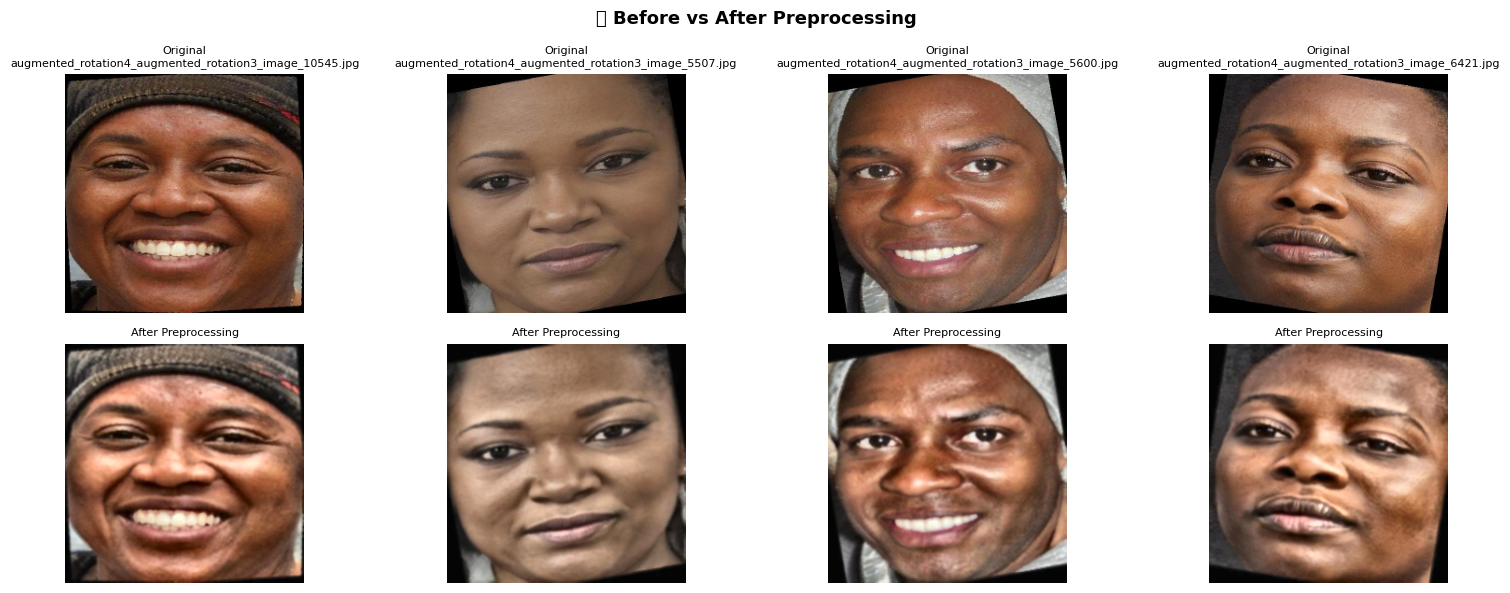

In [ ]:
# ============================================================
# 🧼 FUNGSI PREPROCESSING GAMBAR
# ============================================================

def preprocess_image(img_bgr, apply_blur=True, normalize_lighting=True):
    """
    Preprocessing: blur opsional + normalisasi pencahayaan.

    Args:
        img_bgr           : gambar input (BGR)
        apply_blur        : terapkan Gaussian blur (default True)
        normalize_lighting: normalisasi dengan CLAHE (default True)
    Returns:
        img_processed     : gambar setelah preprocessing (BGR)
    """
    img = img_bgr.copy()

    # --- Gaussian Blur untuk mengurangi noise ---
    if apply_blur:
        img = cv2.GaussianBlur(img, (5, 5), 0)

    # --- Normalisasi pencahayaan dengan CLAHE pada channel L (LAB) ---
    if normalize_lighting:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return img


# Terapkan preprocessing ke semua gambar
preprocessed_dataset = []
for fname, img in dataset:
    img_proc = preprocess_image(img, apply_blur=True, normalize_lighting=True)
    preprocessed_dataset.append((fname, img_proc))

print(f"✅ Preprocessing selesai untuk {len(preprocessed_dataset)} gambar")

# --- Visualisasi Before vs After Preprocessing ---
fig, axes = plt.subplots(2, min(4, len(dataset)), figsize=(16, 6))
fig.suptitle("🧼 Before vs After Preprocessing", fontsize=13, fontweight='bold')

n_show = min(4, len(dataset))
for i in range(n_show):
    fname, orig  = dataset[i]
    _, processed = preprocessed_dataset[i]

    axes[0, i].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Original\n{fname}", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("After Preprocessing", fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 🎯 4. Skin Segmentation (Rule-Based Thresholding)

In [ ]:
# ============================================================
# 🎯 FUNGSI SEGMENTASI KULIT - RULE-BASED THRESHOLDING
# Kombinasi RGB + HSV + YCrCb thresholding
# ============================================================

def segment_skin_rgb(img_bgr):
    """
    Segmentasi kulit menggunakan threshold pada color space RGB.
    Rule: R > 95, G > 40, B > 20, R > G, R > B, |R-G| > 15
    """
    img = img_bgr.astype(np.float32)
    R, G, B = img[:,:,2], img[:,:,1], img[:,:,0]

    mask = (
        (R > 95) & (G > 40) & (B > 20) &
        (R > G)  & (R > B)  &
        (np.abs(R.astype(int) - G.astype(int)) > 15) &
        (np.max(img, axis=2) - np.min(img, axis=2) > 15)
    ).astype(np.uint8) * 255

    return mask


def segment_skin_hsv(img_bgr):
    """
    Segmentasi kulit menggunakan threshold pada color space HSV.
    Rule: H in [0,25] or [335,360], S in [0.10, 0.68], V > 0.35
    """
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

    # OpenCV: H ∈ [0,179], S ∈ [0,255], V ∈ [0,255]
    mask_lower = cv2.inRange(img_hsv, (0,  25,  90), (25, 173, 255))
    mask_upper = cv2.inRange(img_hsv, (160, 25,  90), (179, 173, 255))
    mask = cv2.bitwise_or(mask_lower, mask_upper)

    return mask


def segment_skin_ycrcb(img_bgr):
    """
    Segmentasi kulit menggunakan threshold pada color space YCrCb.
    Rule: Cr ∈ [133,173], Cb ∈ [77,127] — sangat robust untuk berbagai warna kulit
    """
    img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    mask = cv2.inRange(img_ycrcb, (0, 133, 77), (255, 173, 127))
    return mask


def segment_skin_combined(img_bgr, use_morphology=True):
    """
    Segmentasi kulit dengan menggabungkan tiga metode: RGB, HSV, YCrCb.
    Menggunakan voting (pixel dianggap kulit jika minimal 2 dari 3 metode setuju).

    Args:
        img_bgr        : gambar input (BGR)
        use_morphology : terapkan operasi morfologi untuk membersihkan mask
    Returns:
        mask_combined  : binary mask (0/255)
        masks_dict     : dict berisi mask per metode
    """
    mask_rgb   = segment_skin_rgb(img_bgr)
    mask_hsv   = segment_skin_hsv(img_bgr)
    mask_ycrcb = segment_skin_ycrcb(img_bgr)

    # Voting: setidaknya 2 dari 3 metode harus setuju
    vote = (mask_rgb.astype(np.uint16) // 255 +
            mask_hsv.astype(np.uint16) // 255 +
            mask_ycrcb.astype(np.uint16) // 255)
    mask_combined = (vote >= 2).astype(np.uint8) * 255

    # Operasi morfologi untuk mengisi lubang dan menghilangkan noise
    if use_morphology:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask_combined = cv2.morphologyEx(mask_combined, cv2.MORPH_CLOSE, kernel)
        mask_combined = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN, kernel)

    return mask_combined, {
        'RGB': mask_rgb,
        'HSV': mask_hsv,
        'YCrCb': mask_ycrcb,
        'Combined': mask_combined
    }


print("✅ Fungsi segmentasi kulit siap!")

✅ Fungsi segmentasi kulit siap!


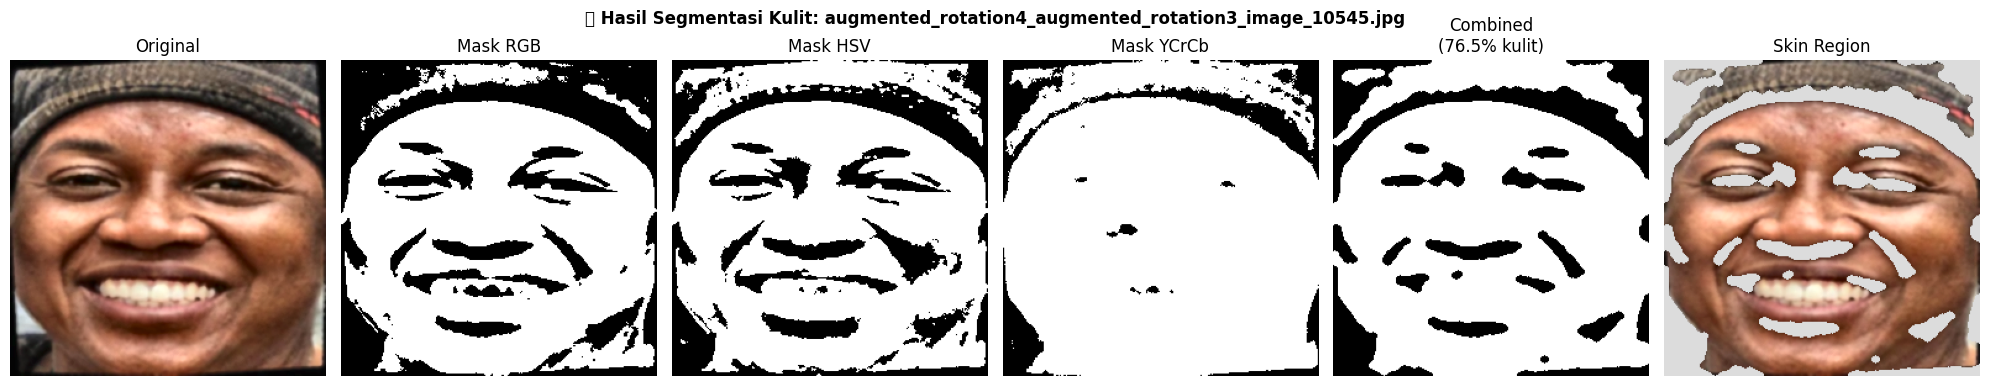

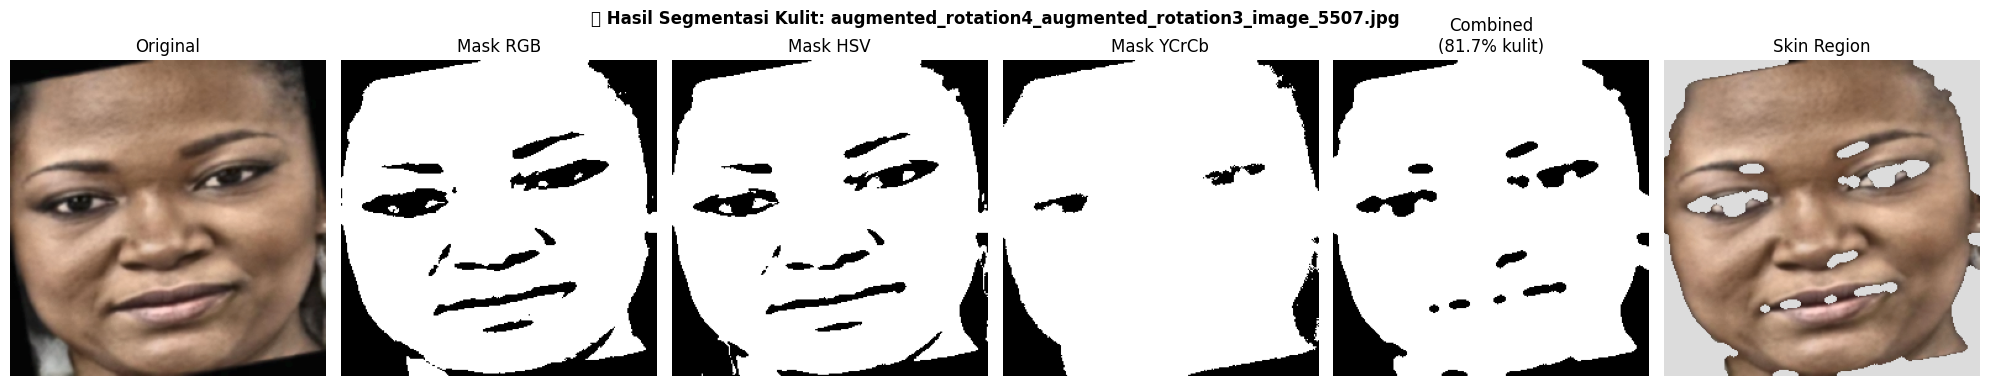

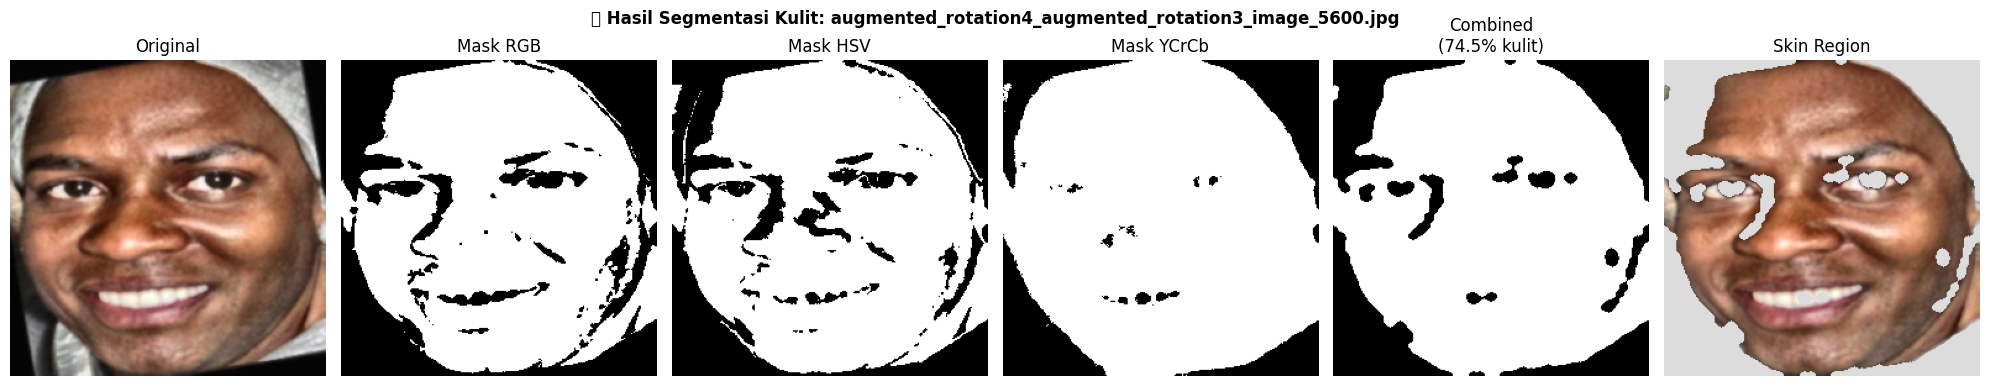

In [ ]:
# ============================================================
# 🔍 VISUALISASI HASIL SEGMENTASI KULIT
# ============================================================

def visualize_segmentation(img_bgr, fname=""):
    """Menampilkan hasil segmentasi semua metode pada satu gambar."""
    mask_combined, masks = segment_skin_combined(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 6, figsize=(20, 4))
    fig.suptitle(f"🎯 Hasil Segmentasi Kulit: {fname}",
                 fontsize=12, fontweight='bold')

    # 1. Gambar asli
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")

    # 2. Mask RGB
    axes[1].imshow(masks['RGB'], cmap='gray')
    axes[1].set_title("Mask RGB")

    # 3. Mask HSV
    axes[2].imshow(masks['HSV'], cmap='gray')
    axes[2].set_title("Mask HSV")

    # 4. Mask YCrCb
    axes[3].imshow(masks['YCrCb'], cmap='gray')
    axes[3].set_title("Mask YCrCb")

    # 5. Mask Combined
    axes[4].imshow(mask_combined, cmap='gray')
    pct = (mask_combined > 0).mean() * 100
    axes[4].set_title(f"Combined\n({pct:.1f}% kulit)")

    # 6. Overlay hasil
    skin_only = img_rgb.copy()
    skin_only[mask_combined == 0] = [220, 220, 220]
    axes[5].imshow(skin_only)
    axes[5].set_title("Skin Region")

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Tampilkan segmentasi untuk 3 gambar pertama
for fname, img in preprocessed_dataset[:3]:
    visualize_segmentation(img, fname)

## 🎨 5. Ekstraksi Pixel Kulit

In [ ]:
# ============================================================
# 🎨 EKSTRAKSI PIXEL KULIT DARI SEMUA GAMBAR
# ============================================================

def extract_skin_pixels(img_bgr, color_space='RGB', min_pixels=50):
    """
    Ekstrak pixel kulit dari gambar dan konversi ke color space tertentu.

    Args:
        img_bgr      : gambar input (BGR)
        color_space  : 'RGB', 'HSV', atau 'LAB'
        min_pixels   : minimum pixel kulit yang diperlukan
    Returns:
        pixels       : array (N, 3) pixel kulit dalam color space yang dipilih
        mask         : mask kulit (0/255)
    """
    mask, _ = segment_skin_combined(img_bgr)

    # Konversi ke color space yang diinginkan
    if color_space == 'RGB':
        img_cs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    elif color_space == 'HSV':
        img_cs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    elif color_space == 'LAB':
        img_cs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    else:
        raise ValueError(f"Color space '{color_space}' tidak dikenal.")

    # Ambil pixel yang termasuk kulit
    pixels = img_cs[mask > 0].reshape(-1, 3).astype(np.float32)

    if len(pixels) < min_pixels:
        return None, mask

    return pixels, mask


def collect_all_skin_pixels(dataset, color_space='RGB'):
    """
    Kumpulkan semua pixel kulit dari seluruh dataset.

    Returns:
        all_pixels : array (N_total, 3)
    """
    all_pixels = []
    n_success = 0
    for fname, img in dataset:
        pixels, _ = extract_skin_pixels(img, color_space)
        if pixels is not None:
            all_pixels.append(pixels)
            n_success += 1

    print(f"  [{color_space}] Ekstraksi dari {n_success}/{len(dataset)} gambar")

    if all_pixels:
        return np.vstack(all_pixels)
    return np.array([])


# Kumpulkan pixel untuk masing-masing color space
print("🎨 Mengekstrak pixel kulit untuk setiap color space...")
pixels_rgb = collect_all_skin_pixels(preprocessed_dataset, 'RGB')
pixels_hsv = collect_all_skin_pixels(preprocessed_dataset, 'HSV')
pixels_lab = collect_all_skin_pixels(preprocessed_dataset, 'LAB')

print(f"\n📊 Jumlah pixel kulit yang dikumpulkan:")
print(f"   RGB  : {len(pixels_rgb):,} pixel")
print(f"   HSV  : {len(pixels_hsv):,} pixel")
print(f"   LAB  : {len(pixels_lab):,} pixel")

🎨 Mengekstrak pixel kulit untuk setiap color space...
  [RGB] Ekstraksi dari 159/160 gambar
  [HSV] Ekstraksi dari 159/160 gambar
  [LAB] Ekstraksi dari 159/160 gambar

📊 Jumlah pixel kulit yang dikumpulkan:
   RGB  : 8,538,971 pixel
   HSV  : 8,538,971 pixel
   LAB  : 8,538,971 pixel


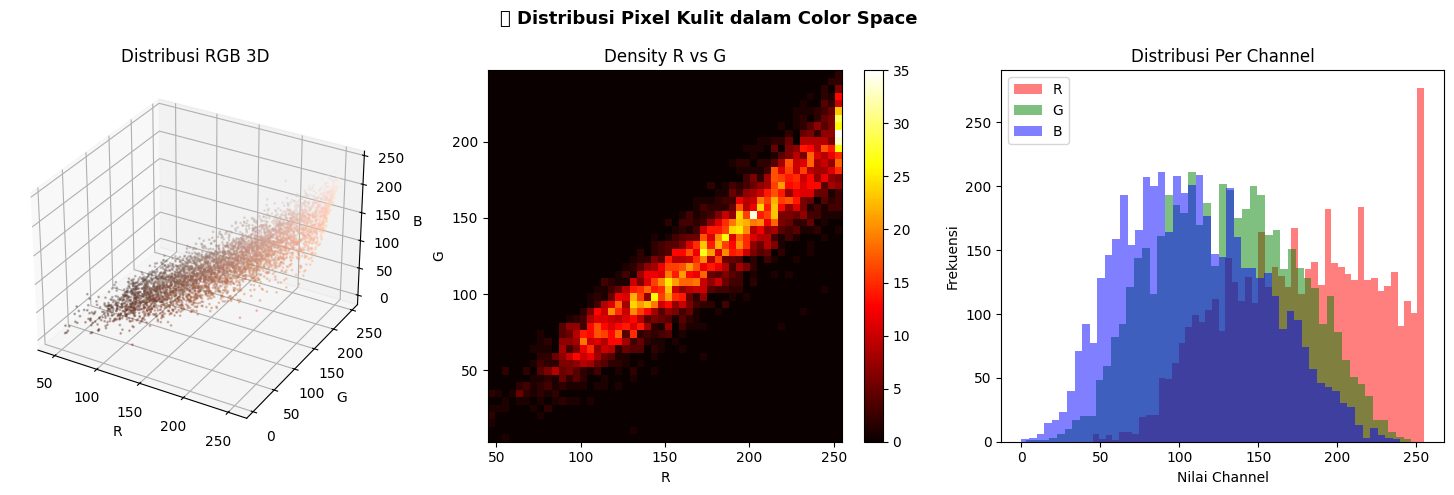

In [ ]:
# ============================================================
# 📊 VISUALISASI DISTRIBUSI PIXEL KULIT (RGB)
# ============================================================

def plot_pixel_distribution(pixels_rgb, n_sample=5000):
    """Plot distribusi warna pixel kulit dalam 3D scatter."""
    # Subsample untuk visualisasi
    if len(pixels_rgb) > n_sample:
        idx = np.random.choice(len(pixels_rgb), n_sample, replace=False)
        sample = pixels_rgb[idx]
    else:
        sample = pixels_rgb

    fig = plt.figure(figsize=(15, 5))
    fig.suptitle("🎨 Distribusi Pixel Kulit dalam Color Space", fontsize=13, fontweight='bold')

    # 3D scatter plot
    ax1 = fig.add_subplot(131, projection='3d')
    colors_norm = sample / 255.0
    ax1.scatter(sample[:, 0], sample[:, 1], sample[:, 2],
                c=colors_norm, s=1, alpha=0.3)
    ax1.set_xlabel('R'); ax1.set_ylabel('G'); ax1.set_zlabel('B')
    ax1.set_title('Distribusi RGB 3D')

    # 2D histogram R-G
    ax2 = fig.add_subplot(132)
    ax2.hist2d(sample[:, 0], sample[:, 1], bins=50, cmap='hot')
    ax2.set_xlabel('R'); ax2.set_ylabel('G')
    ax2.set_title('Density R vs G')
    plt.colorbar(ax2.collections[0], ax=ax2)

    # Channel histogram
    ax3 = fig.add_subplot(133)
    for ch, col, lbl in zip(range(3), ['red','green','blue'], ['R','G','B']):
        ax3.hist(sample[:, ch], bins=50, alpha=0.5, color=col, label=lbl)
    ax3.set_xlabel('Nilai Channel')
    ax3.set_ylabel('Frekuensi')
    ax3.set_title('Distribusi Per Channel')
    ax3.legend()

    plt.tight_layout()
    plt.show()


if len(pixels_rgb) > 0:
    plot_pixel_distribution(pixels_rgb)

## 📊 6. Clustering K-Means + Elbow Method (BONUS)

🔍 Menjalankan Elbow Method pada color space RGB...


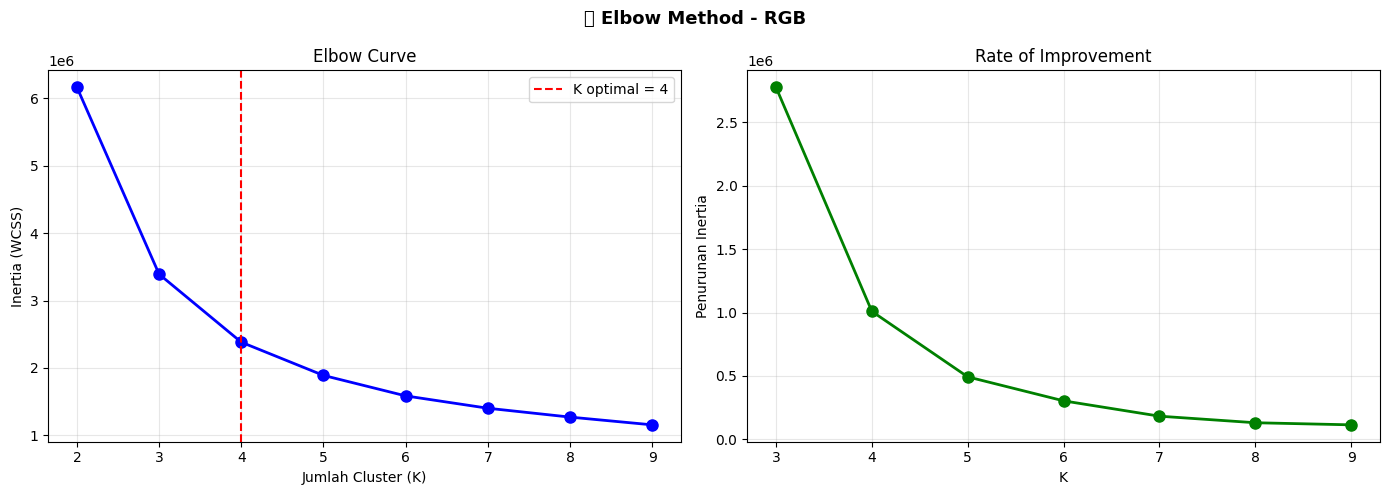

  🎯 K optimal (auto-detect): 4


In [ ]:
# ============================================================
# 📊 FUNGSI CLUSTERING K-MEANS + ELBOW METHOD
# ============================================================

def run_kmeans(pixels, k, random_state=42):
    """
    Jalankan K-Means clustering pada pixel.

    Returns:
        model     : KMeans model yang sudah di-fit
        labels    : label cluster tiap pixel
        centroids : centroid tiap cluster
        inertia   : nilai inertia (WCSS)
    """
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=random_state
    )
    labels = kmeans.fit_predict(pixels)
    return kmeans, labels, kmeans.cluster_centers_, kmeans.inertia_


def elbow_method(pixels, k_range=range(2, 11), color_space='RGB', n_sample=3000):
    """
    Hitung inertia untuk berbagai K dan plot Elbow Curve.
    Secara otomatis pilih K terbaik menggunakan metode selisih kedua (knee point).

    Returns:
        best_k    : K optimal
        inertias  : list nilai inertia per K
    """
    # Subsample untuk kecepatan
    if len(pixels) > n_sample:
        idx = np.random.choice(len(pixels), n_sample, replace=False)
        sample = pixels[idx]
    else:
        sample = pixels

    inertias = []
    k_list = list(k_range)

    for k in k_list:
        _, _, _, inertia = run_kmeans(sample, k)
        inertias.append(inertia)

    # Auto-detect elbow menggunakan second derivative (knee point)
    deltas  = np.diff(inertias)
    deltas2 = np.diff(deltas)
    best_k  = k_list[np.argmax(deltas2) + 2] if len(deltas2) > 0 else k_list[2]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"📈 Elbow Method - {color_space}", fontsize=13, fontweight='bold')

    axes[0].plot(k_list, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].axvline(x=best_k, color='red', linestyle='--',
                    label=f'K optimal = {best_k}')
    axes[0].set_xlabel('Jumlah Cluster (K)')
    axes[0].set_ylabel('Inertia (WCSS)')
    axes[0].set_title('Elbow Curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(k_list[1:], -deltas, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Penurunan Inertia')
    axes[1].set_title('Rate of Improvement')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"  🎯 K optimal (auto-detect): {best_k}")
    return best_k, inertias


# Jalankan Elbow Method untuk RGB
print("🔍 Menjalankan Elbow Method pada color space RGB...")
K_RANGE = range(2, 10)
best_k_rgb, inertias_rgb = elbow_method(pixels_rgb, k_range=K_RANGE, color_space='RGB')

In [ ]:
# ============================================================
# 📊 JALANKAN K-MEANS UNTUK K = 3, 5, 7 (+ K OPTIMAL)
# ============================================================

K_VALUES     = [3, 5, 7]
N_SAMPLE_FIT = 5000  # Sample pixel untuk training (lebih cepat)

def sample_pixels(pixels, n=5000, seed=42):
    """Subsample pixel untuk training K-Means."""
    if len(pixels) > n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(pixels), n, replace=False)
        return pixels[idx]
    return pixels


def fit_kmeans_multiple_k(pixels, k_values, color_space='RGB'):
    """
    Latih K-Means untuk beberapa nilai K.
    Returns:
        results: dict {k: {'model', 'labels', 'centroids', 'inertia'}}
    """
    sample = sample_pixels(pixels, N_SAMPLE_FIT)
    results = {}

    for k in k_values:
        model, labels, centroids, inertia = run_kmeans(sample, k)
        results[k] = {
            'model'    : model,
            'labels'   : labels,
            'centroids': centroids,
            'inertia'  : inertia,
            'pixels'   : sample
        }
        print(f"  [{color_space}] K={k} | Inertia={inertia:.1f}")

    return results


print("🔧 Training K-Means untuk semua nilai K...")
print("\n[RGB]")
results_rgb = fit_kmeans_multiple_k(pixels_rgb, K_VALUES, 'RGB')

print("\n[HSV]")
results_hsv = fit_kmeans_multiple_k(pixels_hsv, K_VALUES, 'HSV')

print("\n[LAB]")
results_lab = fit_kmeans_multiple_k(pixels_lab, K_VALUES, 'LAB')

print("\n✅ Training selesai!")

🔧 Training K-Means untuk semua nilai K...

[RGB]
  [RGB] K=3 | Inertia=5782249.0
  [RGB] K=5 | Inertia=3129864.0
  [RGB] K=7 | Inertia=2329156.2

[HSV]
  [HSV] K=3 | Inertia=8554498.0
  [HSV] K=5 | Inertia=5024021.0
  [HSV] K=7 | Inertia=3614467.5

[LAB]
  [LAB] K=3 | Inertia=1888536.8
  [LAB] K=5 | Inertia=1022704.6
  [LAB] K=7 | Inertia=762735.0

✅ Training selesai!


🎨 Centroid - RGB:


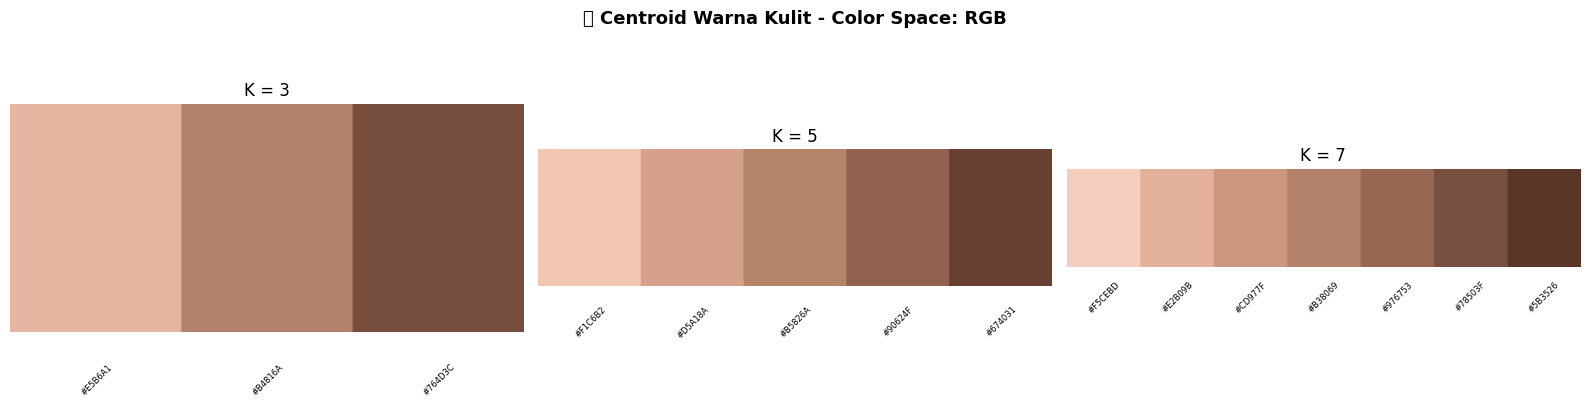

🎨 Centroid - HSV:


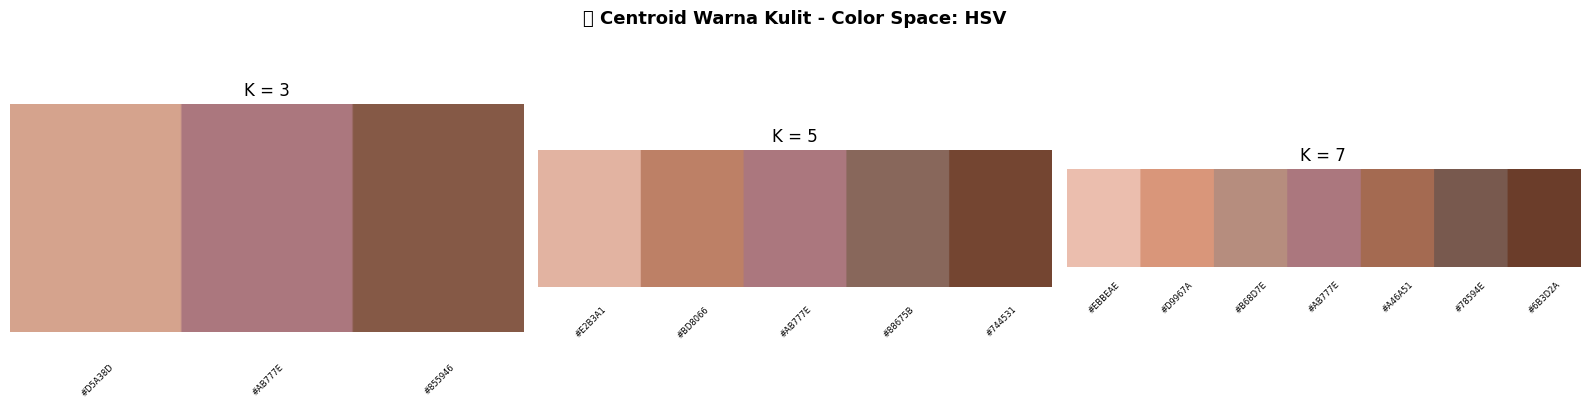

🎨 Centroid - LAB:


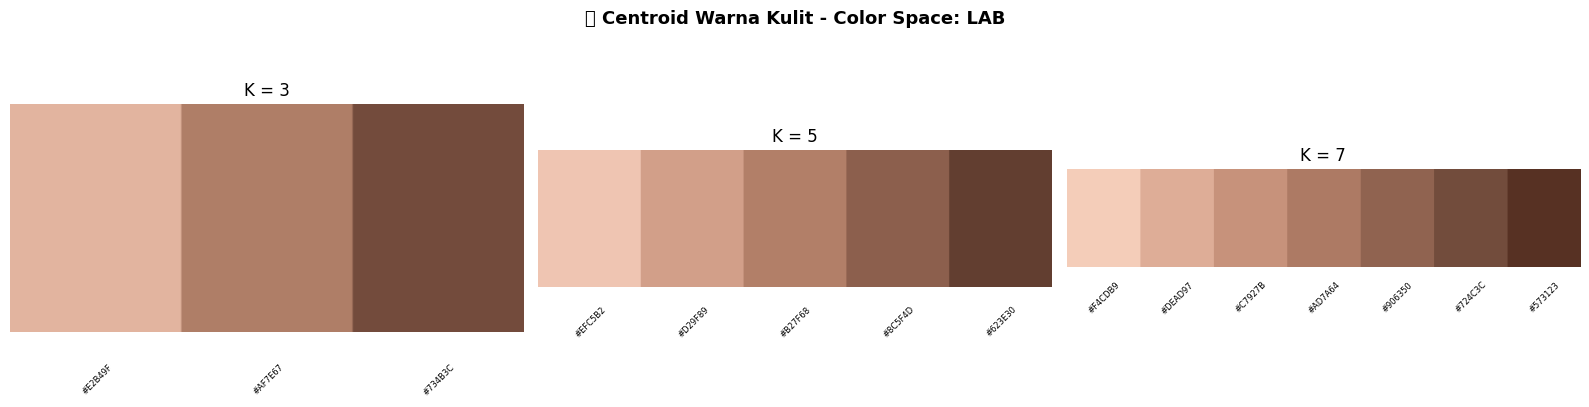

In [ ]:
# ============================================================
# 🎨 VISUALISASI CENTROID WARNA KULIT PER K
# ============================================================

def centroids_rgb_from_space(centroids, color_space):
    """
    Konversi centroid dari color space tertentu kembali ke RGB untuk visualisasi.
    """
    if color_space == 'RGB':
        return centroids.astype(np.uint8)
    elif color_space == 'HSV':
        # Buat gambar 1 piksel, konversi
        result = []
        for c in centroids:
            px = np.uint8([[c]])
            rgb = cv2.cvtColor(px, cv2.COLOR_HSV2RGB)[0][0]
            result.append(rgb)
        return np.array(result, dtype=np.uint8)
    elif color_space == 'LAB':
        result = []
        for c in centroids:
            px = np.uint8([[c]])
            rgb = cv2.cvtColor(px, cv2.COLOR_LAB2RGB)[0][0]
            result.append(rgb)
        return np.array(result, dtype=np.uint8)


def plot_centroids(results, color_space='RGB'):
    """Visualisasi centroid warna untuk tiap K."""
    k_values = list(results.keys())
    fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4))
    fig.suptitle(f"🎨 Centroid Warna Kulit - Color Space: {color_space}",
                 fontsize=13, fontweight='bold')

    for ax, k in zip(axes, k_values):
        centroids = results[k]['centroids']
        rgb_centroids = centroids_rgb_from_space(centroids, color_space)

        # Urutkan berdasarkan kecerahan
        brightness = rgb_centroids.mean(axis=1)
        order = np.argsort(brightness)[::-1]
        rgb_sorted = rgb_centroids[order]

        # Buat bar warna
        palette_img = np.zeros((80, k * 60, 3), dtype=np.uint8)
        for i, rgb in enumerate(rgb_sorted):
            palette_img[:, i*60:(i+1)*60, :] = rgb

        ax.imshow(palette_img)
        ax.set_title(f"K = {k}")
        ax.axis('off')

        # Tambahkan label hex
        for i, rgb in enumerate(rgb_sorted):
            hex_val = '#{:02X}{:02X}{:02X}'.format(*rgb)
            ax.text(i*60 + 30, 90, hex_val, ha='center', va='top',
                    fontsize=6, rotation=45)

    plt.tight_layout()
    plt.show()


print("🎨 Centroid - RGB:")
plot_centroids(results_rgb, 'RGB')

print("🎨 Centroid - HSV:")
plot_centroids(results_hsv, 'HSV')

print("🎨 Centroid - LAB:")
plot_centroids(results_lab, 'LAB')

## 📈 7. Evaluasi Clustering

In [ ]:
# ============================================================
# 📈 FUNGSI EVALUASI CLUSTERING
# Metrik: Silhouette, Davies-Bouldin, Calinski-Harabasz
# ============================================================

def evaluate_clustering(pixels, labels, name=''):
    """
    Hitung semua metrik evaluasi clustering.

    Returns:
        dict berisi semua metrik
    """
    if len(np.unique(labels)) < 2:
        return {'silhouette': 0, 'davies_bouldin': 999, 'calinski_harabasz': 0}

    # Subsample untuk kecepatan
    if len(pixels) > 3000:
        idx = np.random.choice(len(pixels), 3000, replace=False)
        px, lb = pixels[idx], labels[idx]
    else:
        px, lb = pixels, labels

    sil   = silhouette_score(px, lb)
    db    = davies_bouldin_score(px, lb)
    ch    = calinski_harabasz_score(px, lb)

    return {
        'silhouette'          : round(sil, 4),   # ↑ lebih baik (max 1)
        'davies_bouldin'      : round(db,  4),   # ↓ lebih baik (min 0)
        'calinski_harabasz'   : round(ch,  2),   # ↑ lebih baik
    }


def evaluate_all(results_dict, color_space):
    """Evaluasi semua K untuk satu color space."""
    rows = []
    for k, res in results_dict.items():
        metrics = evaluate_clustering(res['pixels'], res['labels'])
        row = {'Color Space': color_space, 'K': k,
               **metrics, 'Inertia': round(res['inertia'], 2)}
        rows.append(row)
    return rows


print("⏳ Menghitung metrik evaluasi (tunggu sebentar)...")
eval_rows  = []
eval_rows += evaluate_all(results_rgb, 'RGB')
eval_rows += evaluate_all(results_hsv, 'HSV')
eval_rows += evaluate_all(results_lab, 'LAB')

df_eval = pd.DataFrame(eval_rows)
print("\n✅ Tabel Evaluasi Clustering:")
print(df_eval.to_string(index=False))

⏳ Menghitung metrik evaluasi (tunggu sebentar)...

✅ Tabel Evaluasi Clustering:
Color Space  K  silhouette  davies_bouldin  calinski_harabasz    Inertia
        RGB  3      0.4797          0.6602        6799.839844 5782249.00
        RGB  5      0.3939          0.7819        6897.569824 3129864.00
        RGB  7      0.3389          0.8839        6365.040039 2329156.25
        HSV  3      0.4504          0.7418        2203.969971 8554498.00
        HSV  5      0.3710          0.8174        2422.060059 5024021.00
        HSV  7      0.3516          0.7871        2429.550049 3614467.50
        LAB  3      0.4746          0.6668        6560.200195 1888536.75
        LAB  5      0.3929          0.7841        6578.549805 1022704.62
        LAB  7      0.3375          0.8793        6247.169922  762735.00


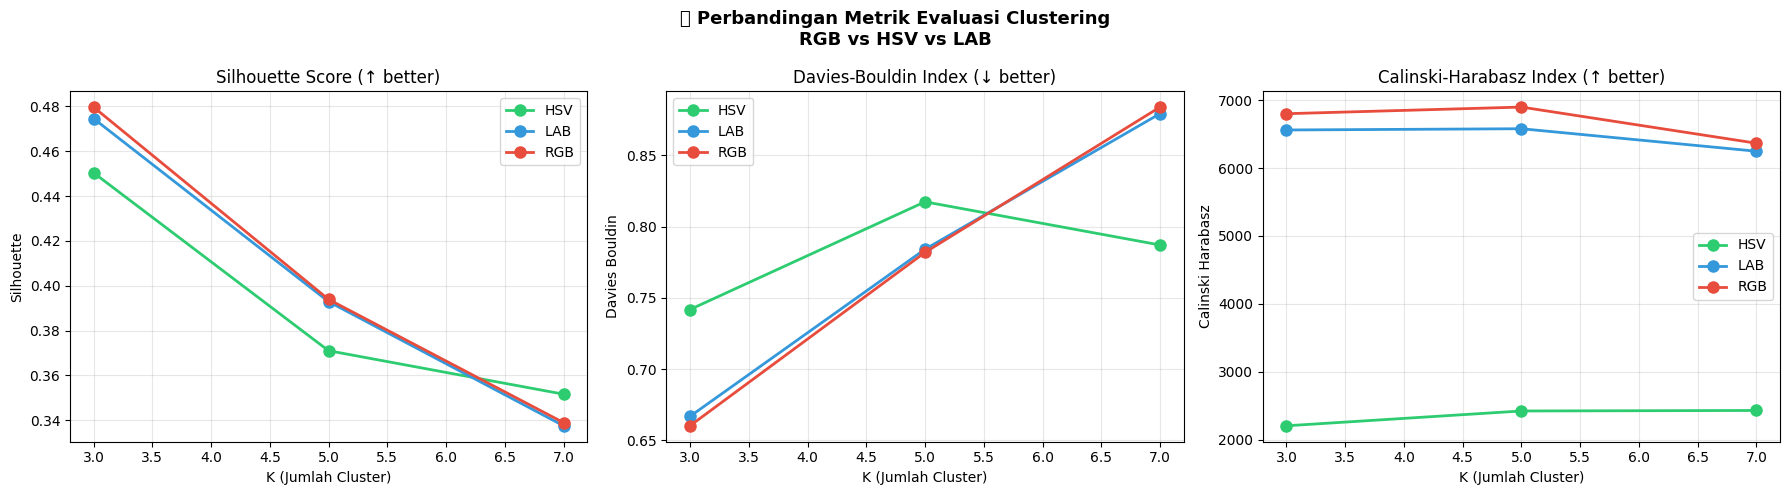

In [ ]:
# ============================================================
# 📊 VISUALISASI PERBANDINGAN METRIK EVALUASI
# ============================================================

def plot_evaluation_comparison(df_eval):
    """Plot metrik evaluasi untuk semua color space dan nilai K."""
    metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
    titles  = ['Silhouette Score (↑ better)',
               'Davies-Bouldin Index (↓ better)',
               'Calinski-Harabasz Index (↑ better)']
    colors  = {'RGB': '#E74C3C', 'HSV': '#2ECC71', 'LAB': '#3498DB'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("📊 Perbandingan Metrik Evaluasi Clustering\nRGB vs HSV vs LAB",
                 fontsize=13, fontweight='bold')

    for ax, metric, title in zip(axes, metrics, titles):
        for cs, grp in df_eval.groupby('Color Space'):
            ax.plot(grp['K'], grp[metric], 'o-',
                    color=colors[cs], label=cs, linewidth=2, markersize=8)
        ax.set_xlabel('K (Jumlah Cluster)')
        ax.set_ylabel(metric.replace('_',' ').title())
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_evaluation_comparison(df_eval)

## 🌈 8. Multi-Color Space Analysis

⏳ Menghitung stabilitas cluster (mungkin butuh ~1 menit)...
  [RGB] K=3 | Stability=0.0204
  [RGB] K=5 | Stability=0.0360
  [RGB] K=7 | Stability=0.0774
  [HSV] K=3 | Stability=0.0411
  [HSV] K=5 | Stability=0.2234
  [HSV] K=7 | Stability=5.1473
  [LAB] K=3 | Stability=0.0391
  [LAB] K=5 | Stability=0.1366
  [LAB] K=7 | Stability=0.0957


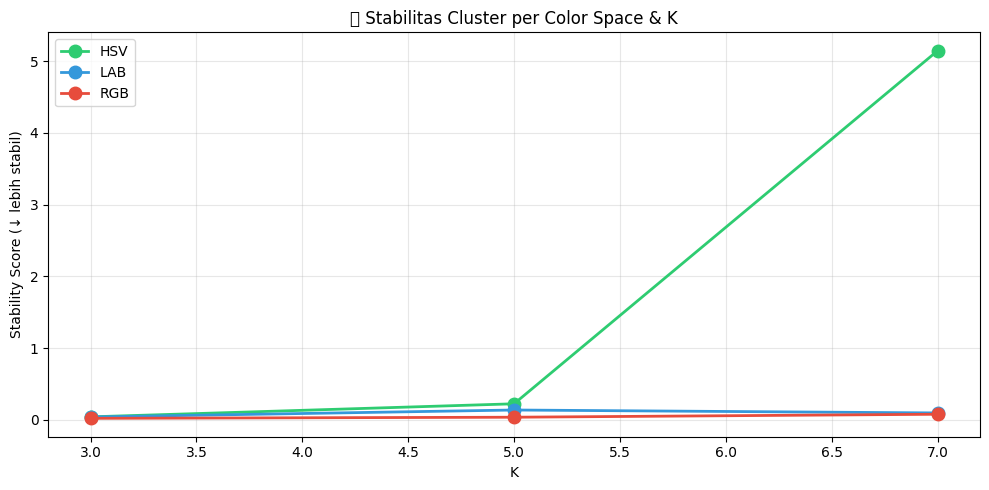


📋 Tabel Stabilitas:
Color Space  K  Stability Score
        RGB  3           0.0204
        RGB  5           0.0360
        RGB  7           0.0774
        HSV  3           0.0411
        HSV  5           0.2234
        HSV  7           5.1473
        LAB  3           0.0391
        LAB  5           0.1366
        LAB  7           0.0957


In [ ]:
# ============================================================
# 🌈 ANALISIS STABILITAS CLUSTER ANTAR COLOR SPACE
# ============================================================

def compute_cluster_stability(pixels, k, n_runs=5, color_space='RGB'):
    """
    Ukur stabilitas cluster dengan menjalankan K-Means beberapa kali
    dan menghitung variasi centroid (std deviation antar run).

    Returns:
        stability_score: semakin kecil semakin stabil
    """
    sample = sample_pixels(pixels, 3000)
    all_centroids = []

    for seed in range(n_runs):
        _, _, centroids, _ = run_kmeans(sample, k, random_state=seed * 10)
        centroids_sorted = centroids[np.argsort(centroids.mean(axis=1))]
        all_centroids.append(centroids_sorted)

    centroid_array  = np.array(all_centroids)  # (n_runs, k, 3)
    stability_score = centroid_array.std(axis=0).mean()  # rata2 std
    return stability_score


print("⏳ Menghitung stabilitas cluster (mungkin butuh ~1 menit)...")
stability_results = []

for cs, pixels in [('RGB', pixels_rgb), ('HSV', pixels_hsv), ('LAB', pixels_lab)]:
    for k in K_VALUES:
        stab = compute_cluster_stability(pixels, k, n_runs=5, color_space=cs)
        stability_results.append({'Color Space': cs, 'K': k,
                                   'Stability Score': round(stab, 4)})
        print(f"  [{cs}] K={k} | Stability={stab:.4f}")

df_stability = pd.DataFrame(stability_results)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'RGB': '#E74C3C', 'HSV': '#2ECC71', 'LAB': '#3498DB'}
for cs, grp in df_stability.groupby('Color Space'):
    ax.plot(grp['K'], grp['Stability Score'], 'o-',
            color=colors[cs], label=cs, linewidth=2, markersize=9)
ax.set_xlabel('K')
ax.set_ylabel('Stability Score (↓ lebih stabil)')
ax.set_title('🌈 Stabilitas Cluster per Color Space & K')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Tabel Stabilitas:")
print(df_stability.to_string(index=False))

## 🎯 9. Pemilihan Model Terbaik


📊 Tabel Skor Komposit (Top 5):
Color Space  K  silhouette  davies_bouldin  calinski_harabasz  Stability Score  composite
        RGB  3      0.4797          0.6602        6799.839844           0.0204   0.995836
        LAB  3      0.4746          0.6668        6560.200195           0.0391   0.964966
        RGB  5      0.3939          0.7819        6897.569824           0.0360   0.652202
        HSV  3      0.4504          0.7418        2203.969971           0.0411   0.635882
        LAB  5      0.3929          0.7841        6578.549805           0.1366   0.629764

🏆 MODEL TERBAIK:
   Color Space : RGB
   K optimal   : 3
   Composite   : 0.9958
   Silhouette  : 0.4797
   DB Index    : 0.6602
   CH Index    : 6799.84


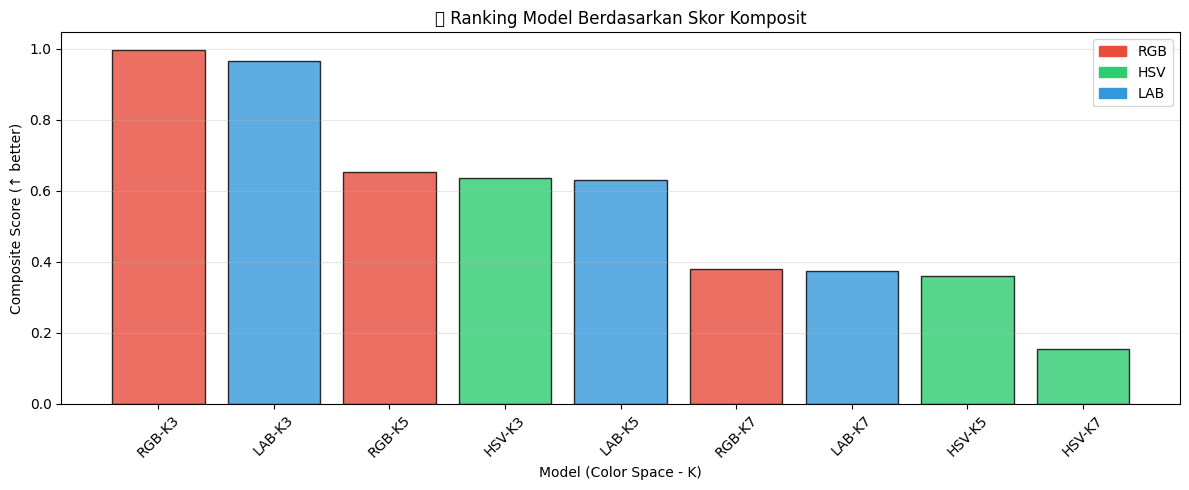

In [ ]:
# ============================================================
# 🎯 PEMILIHAN MODEL TERBAIK (Scoring Komposit)
# ============================================================

def select_best_model(df_eval, df_stability):
    """
    Gabungkan semua metrik menjadi skor komposit dan pilih model terbaik.

    Normalisasi:
      - Silhouette      : ↑ better → normalize 0-1
      - Davies-Bouldin  : ↓ better → inverse normalize
      - Calinski-Harabasz: ↑ better → normalize 0-1
      - Stability       : ↓ better → inverse normalize
    """
    df = df_eval.merge(df_stability, on=['Color Space', 'K'])

    def norm_up(x):   return (x - x.min()) / (x.max() - x.min() + 1e-9)
    def norm_down(x): return 1 - norm_up(x)

    df['score_sil']    = norm_up(df['silhouette'])
    df['score_db']     = norm_down(df['davies_bouldin'])
    df['score_ch']     = norm_up(df['calinski_harabasz'])
    df['score_stab']   = norm_down(df['Stability Score'])

    # Bobot: silhouette & stabilitas lebih penting
    df['composite'] = (0.35 * df['score_sil'] +
                       0.25 * df['score_db']  +
                       0.20 * df['score_ch']  +
                       0.20 * df['score_stab'])

    df_sorted = df.sort_values('composite', ascending=False)
    best = df_sorted.iloc[0]

    print("\n📊 Tabel Skor Komposit (Top 5):")
    cols = ['Color Space', 'K', 'silhouette', 'davies_bouldin',
            'calinski_harabasz', 'Stability Score', 'composite']
    print(df_sorted[cols].head(5).to_string(index=False))

    print(f"\n🏆 MODEL TERBAIK:")
    print(f"   Color Space : {best['Color Space']}")
    print(f"   K optimal   : {int(best['K'])}")
    print(f"   Composite   : {best['composite']:.4f}")
    print(f"   Silhouette  : {best['silhouette']:.4f}")
    print(f"   DB Index    : {best['davies_bouldin']:.4f}")
    print(f"   CH Index    : {best['calinski_harabasz']:.2f}")

    return best['Color Space'], int(best['K']), df_sorted


best_cs, best_k, df_ranked = select_best_model(df_eval, df_stability)

# Visualisasi skor komposit
fig, ax = plt.subplots(figsize=(12, 5))
colors_map = {'RGB': '#E74C3C', 'HSV': '#2ECC71', 'LAB': '#3498DB'}

for _, row in df_ranked.iterrows():
    label = f"{row['Color Space']}-K{int(row['K'])}"
    bar = ax.bar(label, row['composite'],
                 color=colors_map[row['Color Space']], alpha=0.8, edgecolor='black')

ax.set_xlabel('Model (Color Space - K)')
ax.set_ylabel('Composite Score (↑ better)')
ax.set_title('🏆 Ranking Model Berdasarkan Skor Komposit')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 👕 10. Sistem Rekomendasi Warna Pakaian

In [ ]:
# ============================================================
# 🎨 FUNGSI COLOR HARMONY
# Menghasilkan warna pakaian berdasarkan teori color harmony
# ============================================================

def rgb_to_hsv_single(rgb):
    """Konversi satu warna RGB [0-255] ke HSV [H:0-360, S:0-1, V:0-1]."""
    r, g, b = [x / 255.0 for x in rgb]
    mx, mn  = max(r,g,b), min(r,g,b)
    diff    = mx - mn
    v       = mx
    s       = 0 if mx == 0 else diff / mx
    if diff == 0:
        h = 0
    elif mx == r:
        h = (60 * ((g - b) / diff) + 360) % 360
    elif mx == g:
        h = 60 * ((b - r) / diff) + 120
    else:
        h = 60 * ((r - g) / diff) + 240
    return h, s, v


def hsv_to_rgb_single(h, s, v):
    """Konversi satu warna HSV [H:0-360, S:0-1, V:0-1] ke RGB [0-255]."""
    h = h % 360
    c = v * s
    x = c * (1 - abs((h / 60) % 2 - 1))
    m = v - c
    if   h < 60 : r1,g1,b1 = c, x, 0
    elif h < 120: r1,g1,b1 = x, c, 0
    elif h < 180: r1,g1,b1 = 0, c, x
    elif h < 240: r1,g1,b1 = 0, x, c
    elif h < 300: r1,g1,b1 = x, 0, c
    else        : r1,g1,b1 = c, 0, x
    return tuple(int((c2+m)*255) for c2 in (r1,g1,b1))


def complementary_colors(skin_rgb, adjust_brightness=True):
    """Warna komplementer: hue + 180°, disesuaikan untuk pakaian."""
    h, s, v = rgb_to_hsv_single(skin_rgb)
    # Sesuaikan saturasi & kecerahan agar menarik untuk pakaian
    colors  = []
    for s_adj, v_adj in [(0.7, 0.85), (0.5, 0.65), (0.85, 0.95)]:
        c = hsv_to_rgb_single((h + 180) % 360, min(s_adj, 1), v_adj)
        colors.append(c)
    return colors


def analogous_colors(skin_rgb):
    """Warna analogous: hue ± 30° & ± 60° dari skin tone."""
    h, s, v = rgb_to_hsv_single(skin_rgb)
    offsets = [30, -30, 60, -60]
    colors  = []
    for off in offsets:
        s_new = min(max(s * 0.8, 0.3), 0.9)
        v_new = min(max(v * 1.1, 0.5), 0.95)
        colors.append(hsv_to_rgb_single((h + off) % 360, s_new, v_new))
    return colors


def triadic_colors(skin_rgb):
    """Warna triadic: hue + 120° dan + 240°."""
    h, s, v = rgb_to_hsv_single(skin_rgb)
    colors  = []
    for off in [120, 240]:
        for s_adj in [0.6, 0.8]:
            v_adj = min(v * 1.05, 0.9)
            colors.append(hsv_to_rgb_single((h + off) % 360, s_adj, v_adj))
    return colors


def neutral_colors(skin_rgb):
    """Warna netral yang cocok untuk hampir semua warna kulit."""
    h, s, v = rgb_to_hsv_single(skin_rgb)
    # Cream, putih hangat, abu-abu, navy, coklat gelap
    neutrals = [
        (245, 240, 230),  # Cream
        (255, 250, 240),  # Floral White
        (128, 128, 128),  # Medium Gray
        (30,  30,  60),   # Dark Navy
        (101, 67,  33),   # Dark Brown
    ]
    return neutrals


print("✅ Fungsi Color Harmony siap!")

✅ Fungsi Color Harmony siap!


In [ ]:
# ============================================================
# 🏷️ KLASIFIKASI SKIN TONE (Fitzpatrick Scale)
# ============================================================

def classify_skin_tone(rgb):
    """
    Klasifikasikan warna kulit ke dalam kategori berdasarkan
    nilai brightness dan saturasi.

    Returns:
        category : 'Very Fair', 'Fair', 'Medium', 'Olive', 'Brown', 'Dark'
    """
    h, s, v = rgb_to_hsv_single(rgb)
    brightness = v  # 0-1

    if brightness > 0.90 and s < 0.25:
        return 'Very Fair'
    elif brightness > 0.80:
        return 'Fair'
    elif brightness > 0.65:
        return 'Medium'
    elif brightness > 0.50:
        return 'Olive'
    elif brightness > 0.30:
        return 'Brown'
    else:
        return 'Dark'


# Mapping skin tone ke strategi rekomendasi warna khusus
SKIN_TONE_STRATEGY = {
    'Very Fair': {
        'avoid': 'Hindari warna terlalu pucat (putih murni)',
        'prefer': 'Cocok dengan warna jewel tones: emerald, sapphire, burgundy'
    },
    'Fair': {
        'avoid': 'Hindari warna orange yang terlalu terang',
        'prefer': 'Cocok dengan pink, lavender, biru muda, coral'
    },
    'Medium': {
        'avoid': 'Hindari warna terlalu neon',
        'prefer': 'Cocok dengan earth tones, olive green, coral, marun'
    },
    'Olive': {
        'avoid': 'Hindari yellow-green yang terlalu mudah',
        'prefer': 'Cocok dengan gold, orange, teal, rust, cream'
    },
    'Brown': {
        'avoid': 'Hindari coklat yang terlalu mirip warna kulit',
        'prefer': 'Cocok dengan bright colors: orange, yellow, royal blue, red'
    },
    'Dark': {
        'avoid': 'Hindari warna gelap yang menyatu',
        'prefer': 'Cocok dengan vivid colors: bright red, lime, turquoise, magenta'
    },
}

print("✅ Fungsi klasifikasi skin tone siap!")

✅ Fungsi klasifikasi skin tone siap!


In [ ]:
# ============================================================
# 👕 ENGINE REKOMENDASI WARNA PAKAIAN
# ============================================================

def get_clothing_recommendations(skin_centroid_rgb):
    """
    Dapatkan rekomendasi warna pakaian berdasarkan warna kulit.

    Args:
        skin_centroid_rgb: tuple (R, G, B) warna kulit dominan
    Returns:
        dict berisi rekomendasi per kategori harmony
    """
    skin_rgb    = tuple(int(x) for x in skin_centroid_rgb)
    tone_cat    = classify_skin_tone(skin_rgb)
    strategy    = SKIN_TONE_STRATEGY.get(tone_cat, {})

    rec = {
        'skin_rgb'       : skin_rgb,
        'skin_hex'       : '#{:02X}{:02X}{:02X}'.format(*skin_rgb),
        'skin_tone'      : tone_cat,
        'strategy'       : strategy,
        'complementary'  : complementary_colors(skin_rgb),
        'analogous'      : analogous_colors(skin_rgb),
        'triadic'        : triadic_colors(skin_rgb),
        'neutral'        : neutral_colors(skin_rgb),
    }

    # Gabungkan semua rekomendasi
    all_colors = []
    for cat in ['complementary', 'analogous', 'triadic', 'neutral']:
        all_colors.extend(rec[cat])
    rec['all_colors'] = all_colors

    return rec


def visualize_recommendations(rec):
    """Visualisasi lengkap palette rekomendasi pakaian."""
    categories = ['complementary', 'analogous', 'triadic', 'neutral']
    cat_labels = ['Complementary', 'Analogous', 'Triadic', 'Neutral']
    cat_colors = ['#E74C3C', '#2ECC71', '#3498DB', '#95A5A6']

    fig = plt.figure(figsize=(18, 10))
    gs  = fig.add_gridspec(3, 1, hspace=0.5)
    fig.suptitle(
        f"👕 Rekomendasi Warna Pakaian\n"
        f"Skin Tone: {rec['skin_tone']} | Skin Color: {rec['skin_hex']}",
        fontsize=14, fontweight='bold'
    )

    # ---- Baris 1: Warna kulit ----
    ax0 = fig.add_subplot(gs[0])
    ax0.set_xlim(0, 10)
    ax0.set_ylim(0, 1)
    ax0.add_patch(plt.Rectangle((0, 0), 10, 1,
                                 color=[x/255 for x in rec['skin_rgb']]))
    ax0.text(5, 0.5,
             f"🧑 Warna Kulit: {rec['skin_hex']} | {rec['skin_tone']}",
             ha='center', va='center', fontsize=12, fontweight='bold',
             color='white' if rec['skin_rgb'][0] < 128 else 'black')
    ax0.axis('off')

    # ---- Baris 2: Rekomendasi per kategori ----
    ax1 = fig.add_subplot(gs[1])
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, len(categories))
    ax1.axis('off')

    for row_idx, (cat, label, hdr_color) in enumerate(
            zip(categories, cat_labels, cat_colors)):
        y_pos = len(categories) - 1 - row_idx
        colors_in_cat = rec[cat]
        n = len(colors_in_cat)
        swatch_w = 0.1
        start_x  = 0.2

        # Label kategori
        ax1.text(0.0, y_pos + 0.5, label, va='center',
                 fontsize=10, fontweight='bold', color=hdr_color)

        # Swatch warna
        for i, rgb in enumerate(colors_in_cat):
            x = start_x + i * (swatch_w + 0.01)
            rgb_norm = [v/255 for v in rgb]
            ax1.add_patch(plt.Rectangle((x, y_pos + 0.05), swatch_w, 0.85,
                                         color=rgb_norm))
            hex_str = '#{:02X}{:02X}{:02X}'.format(*rgb)
            ax1.text(x + swatch_w/2, y_pos + 0.03, hex_str,
                     ha='center', va='top', fontsize=6, rotation=45)

    # ---- Baris 3: Tips strategi ----
    ax2 = fig.add_subplot(gs[2])
    ax2.axis('off')
    strategy = rec.get('strategy', {})
    tips_text = (
        f"💡 Tips untuk skin tone '{rec['skin_tone']}':\n"
        f"  ✅ {strategy.get('prefer', '-')}\n"
        f"  ❌ {strategy.get('avoid', '-')}"
    )
    ax2.text(0.05, 0.7, tips_text, transform=ax2.transAxes,
             fontsize=11, va='top', bbox=dict(boxstyle='round',
             facecolor='lightyellow', alpha=0.8))

    plt.show()


print("✅ Engine rekomendasi siap!")

✅ Engine rekomendasi siap!



🏆 Model terbaik: RGB | K = 3

Centroid warna kulit (RGB):
  Cluster 1: #B4816A → Medium
  Cluster 2: #764D3C → Brown
  Cluster 3: #E5B6A1 → Fair

👕 HASIL REKOMENDASI WARNA PAKAIAN PER CLUSTER

--- Cluster 1 ---


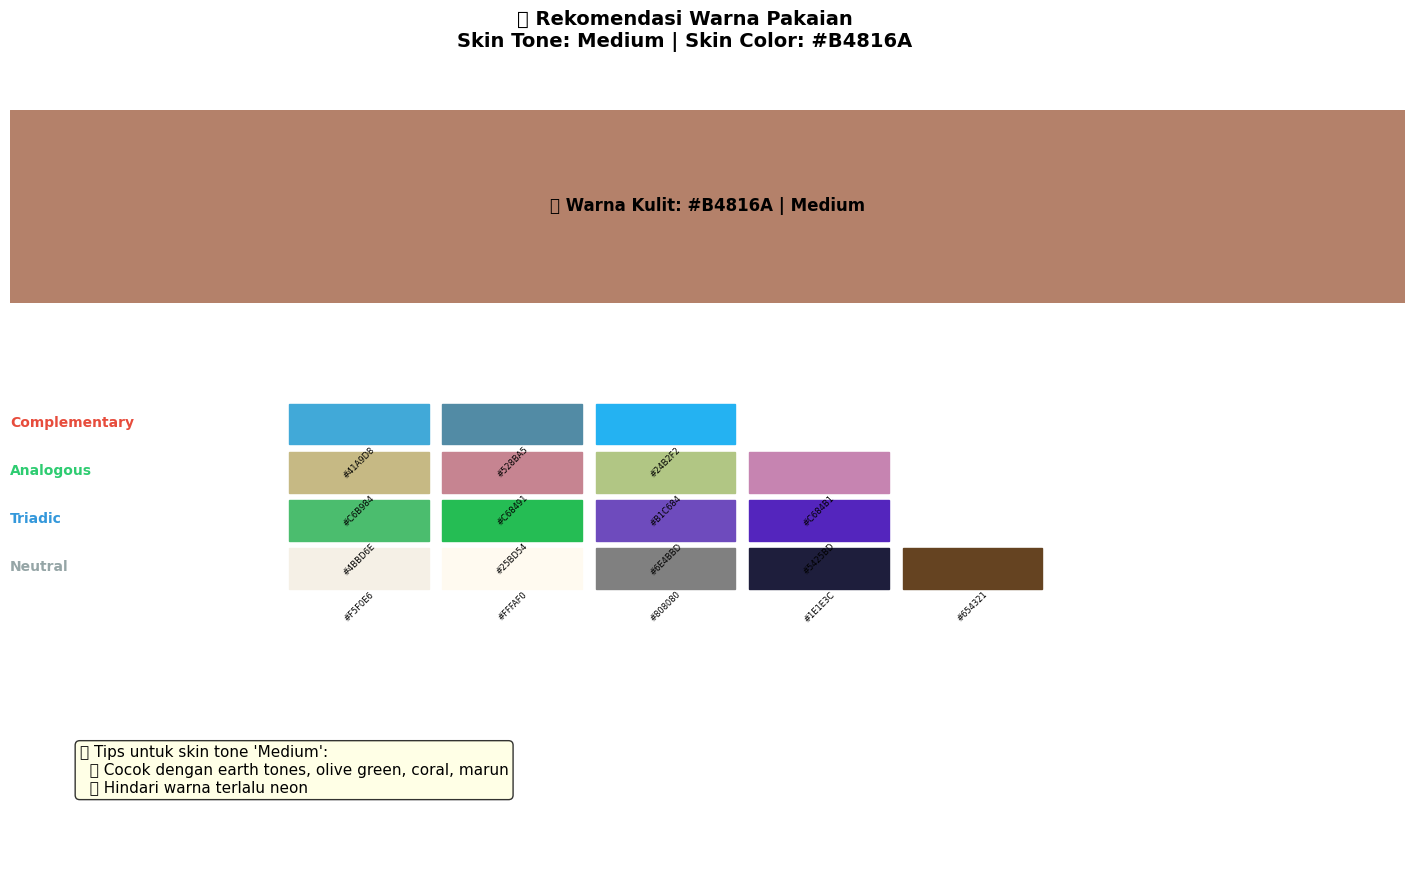


--- Cluster 2 ---


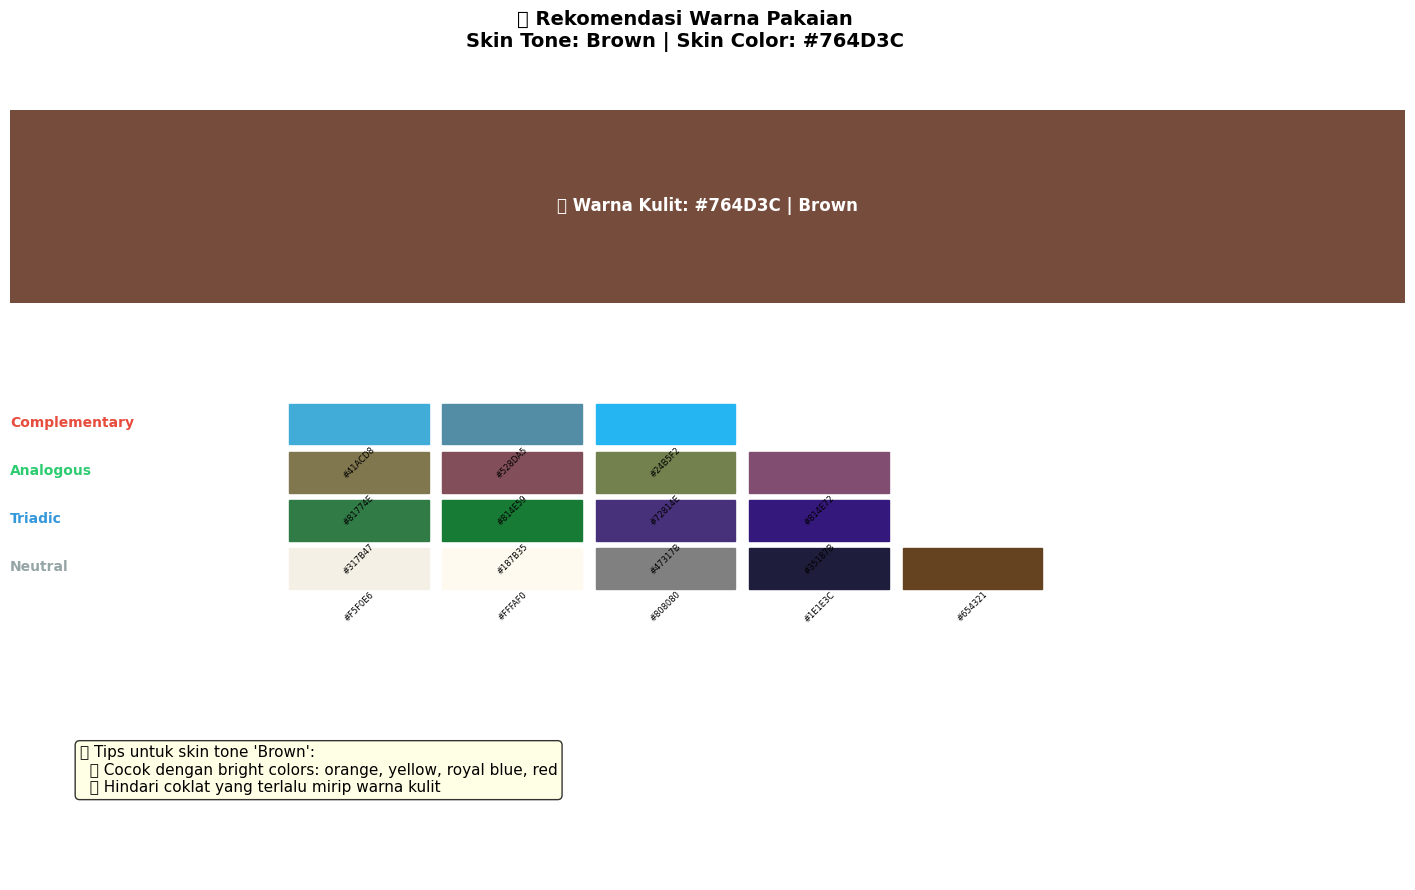


--- Cluster 3 ---


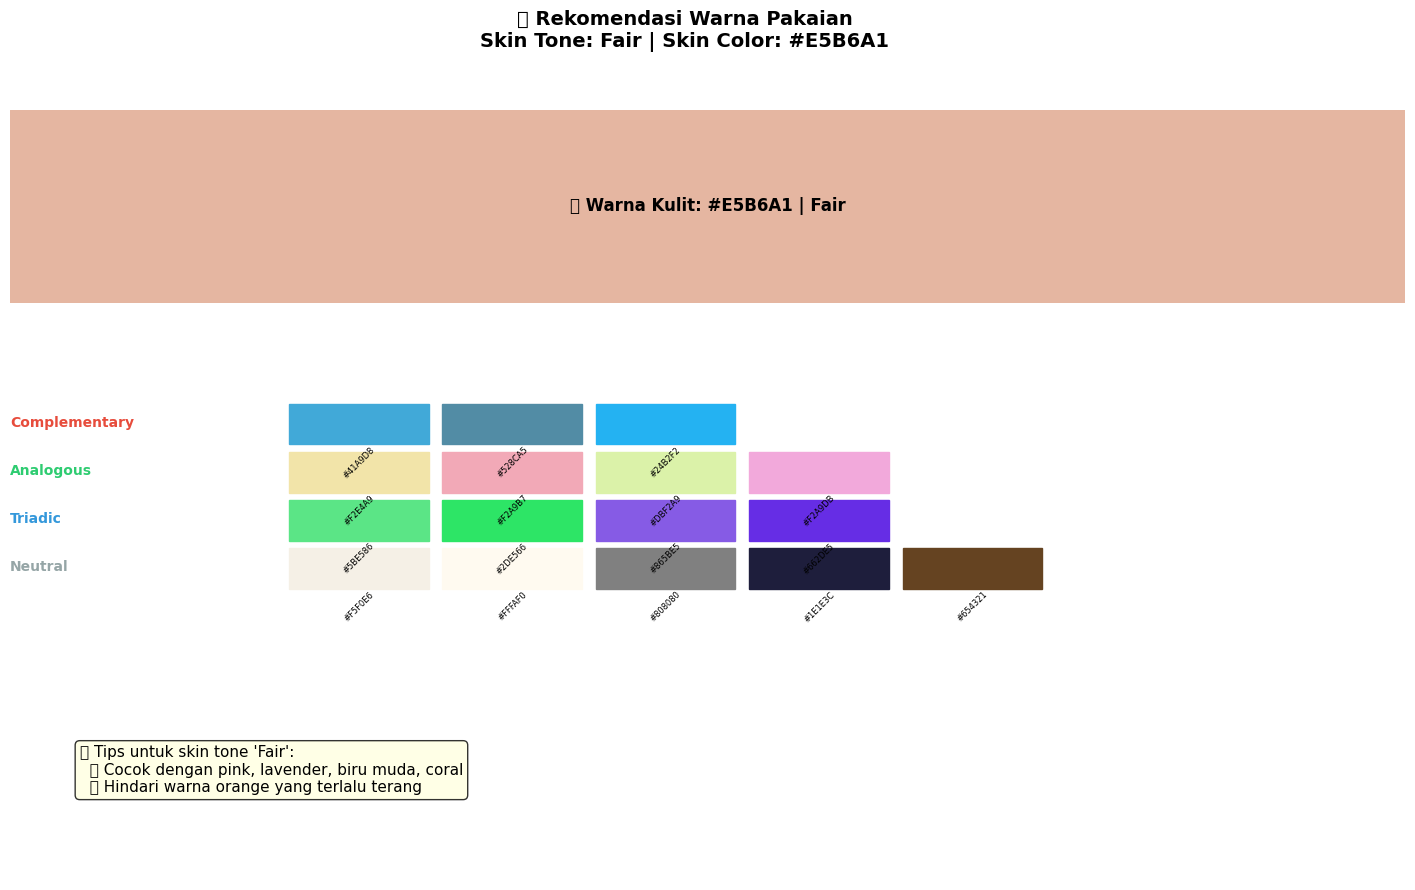

In [ ]:
# ============================================================
# 🚀 JALANKAN REKOMENDASI BERDASARKAN MODEL TERBAIK
# ============================================================

# Ambil model dan centroid terbaik
BEST_RESULTS_MAP = {'RGB': results_rgb, 'HSV': results_hsv, 'LAB': results_lab}
best_model_results = BEST_RESULTS_MAP[best_cs]

# Gunakan K terbaik (fallback ke K_VALUES[0] jika tidak ada di hasil)
if best_k not in best_model_results:
    best_k = K_VALUES[0]

best_centroids_raw = best_model_results[best_k]['centroids']

# Konversi centroid ke RGB
best_centroids_rgb = centroids_rgb_from_space(best_centroids_raw, best_cs)

print(f"\n🏆 Model terbaik: {best_cs} | K = {best_k}")
print(f"\nCentroid warna kulit (RGB):")
for i, c in enumerate(best_centroids_rgb):
    tone = classify_skin_tone(c)
    print(f"  Cluster {i+1}: #{c[0]:02X}{c[1]:02X}{c[2]:02X} → {tone}")

# Tampilkan rekomendasi untuk setiap centroid
print("\n" + "="*60)
print("👕 HASIL REKOMENDASI WARNA PAKAIAN PER CLUSTER")
print("="*60)

for i, centroid_rgb in enumerate(best_centroids_rgb):
    print(f"\n--- Cluster {i+1} ---")
    rec = get_clothing_recommendations(centroid_rgb)
    visualize_recommendations(rec)

## 📊 11. Visualisasi Komprehensif

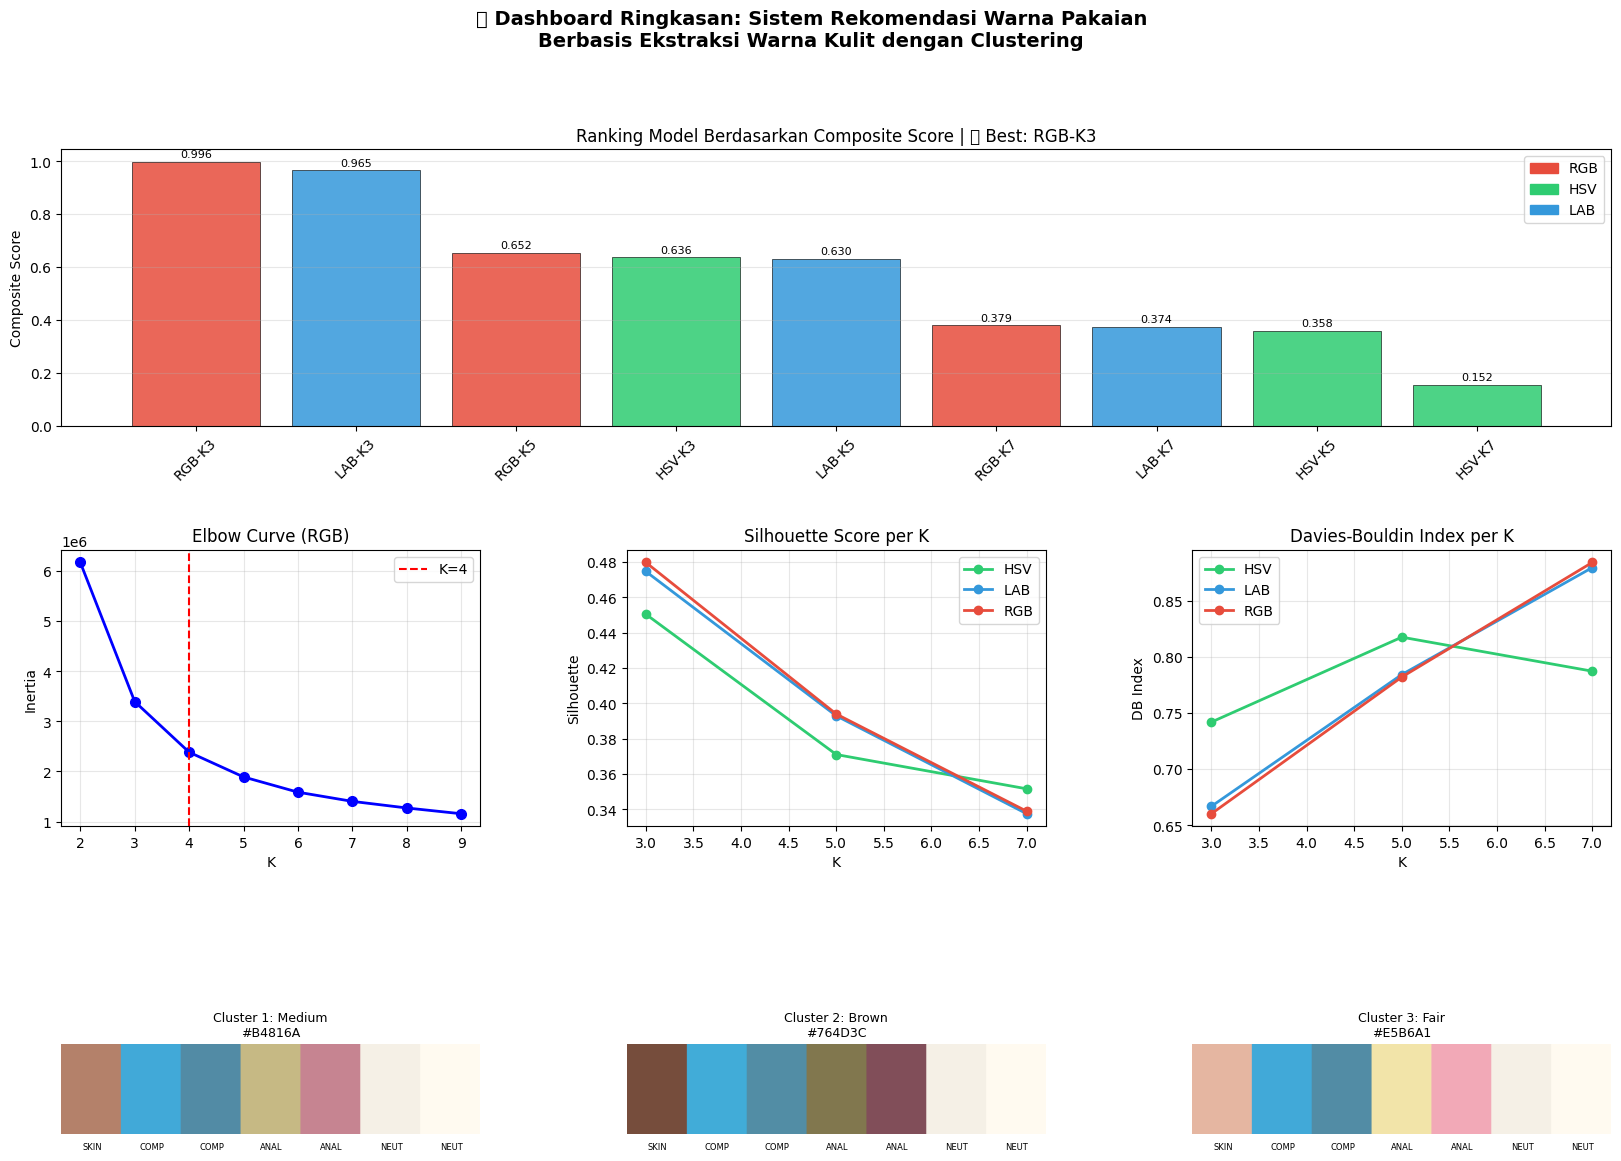


💾 Dashboard disimpan ke /content/dashboard_summary.png


In [ ]:
# ============================================================
# 📊 VISUALISASI KOMPREHENSIF: SUMMARY DASHBOARD
# ============================================================

def plot_summary_dashboard(df_ranked, best_cs, best_k,
                            best_centroids_rgb, results_rgb):
    """Dashboard ringkasan seluruh hasil analisis."""
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        "📊 Dashboard Ringkasan: Sistem Rekomendasi Warna Pakaian\n"
        "Berbasis Ekstraksi Warna Kulit dengan Clustering",
        fontsize=14, fontweight='bold', y=0.98
    )
    gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

    # ---- 1. Ranking model (composite score) ----
    ax1 = fig.add_subplot(gs[0, :])
    cs_colors = {'RGB': '#E74C3C', 'HSV': '#2ECC71', 'LAB': '#3498DB'}
    bar_colors = [cs_colors[row['Color Space']] for _, row in df_ranked.iterrows()]
    labels     = [f"{row['Color Space']}-K{int(row['K'])}" for _, row in df_ranked.iterrows()]
    bars = ax1.bar(labels, df_ranked['composite'], color=bar_colors,
                   alpha=0.85, edgecolor='black', linewidth=0.5)
    ax1.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
    ax1.set_title(f'Ranking Model Berdasarkan Composite Score | 🏆 Best: {best_cs}-K{best_k}')
    ax1.set_ylabel('Composite Score')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    patches = [mpatches.Patch(color=v, label=k) for k,v in cs_colors.items()]
    ax1.legend(handles=patches, loc='upper right')

    # ---- 2. Elbow curve (RGB) ----
    ax2 = fig.add_subplot(gs[1, 0])
    k_list = list(K_RANGE)
    ax2.plot(k_list, inertias_rgb, 'bo-', linewidth=2, markersize=7)
    ax2.axvline(x=best_k_rgb, color='red', linestyle='--',
                label=f'K={best_k_rgb}')
    ax2.set_title('Elbow Curve (RGB)')
    ax2.set_xlabel('K'); ax2.set_ylabel('Inertia')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # ---- 3. Silhouette scores ----
    ax3 = fig.add_subplot(gs[1, 1])
    for cs, grp in df_eval.groupby('Color Space'):
        ax3.plot(grp['K'], grp['silhouette'], 'o-',
                 color=cs_colors[cs], label=cs, linewidth=2)
    ax3.set_title('Silhouette Score per K')
    ax3.set_xlabel('K'); ax3.set_ylabel('Silhouette')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    # ---- 4. Davies-Bouldin scores ----
    ax4 = fig.add_subplot(gs[1, 2])
    for cs, grp in df_eval.groupby('Color Space'):
        ax4.plot(grp['K'], grp['davies_bouldin'], 'o-',
                 color=cs_colors[cs], label=cs, linewidth=2)
    ax4.set_title('Davies-Bouldin Index per K')
    ax4.set_xlabel('K'); ax4.set_ylabel('DB Index')
    ax4.legend(); ax4.grid(True, alpha=0.3)

    # ---- 5-7: Palette warna per cluster ----
    n_centroids = len(best_centroids_rgb)
    for i in range(min(3, n_centroids)):
        ax = fig.add_subplot(gs[2, i])
        skin_rgb = tuple(int(x) for x in best_centroids_rgb[i])
        rec      = get_clothing_recommendations(skin_rgb)
        palette  = [skin_rgb] + rec['complementary'][:2] + rec['analogous'][:2] + rec['neutral'][:2]

        n_sw = len(palette)
        palette_img = np.zeros((60, n_sw * 40, 3), dtype=np.uint8)
        for j, c in enumerate(palette):
            palette_img[:, j*40:(j+1)*40, :] = np.array(c[:3], dtype=np.uint8)

        ax.imshow(palette_img)
        ax.set_title(f"Cluster {i+1}: {rec['skin_tone']}\n{rec['skin_hex']}",
                     fontsize=9)

        # Label
        labels_p = ['SKIN'] + ['COMP']*2 + ['ANAL']*2 + ['NEUT']*2
        for j, lbl in enumerate(labels_p):
            ax.text(j*40+20, 65, lbl, ha='center', va='top', fontsize=6)
        ax.axis('off')

    plt.savefig('/content/dashboard_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n💾 Dashboard disimpan ke /content/dashboard_summary.png")


plot_summary_dashboard(df_ranked, best_cs, best_k, best_centroids_rgb, results_rgb)

## 🧪 12. Testing dengan Gambar Baru

  Unggah gambar dari komputer Anda untuk pengujian:


Saving images (2).jpg to images (2).jpg

  Memproses file: "images (2).jpg"


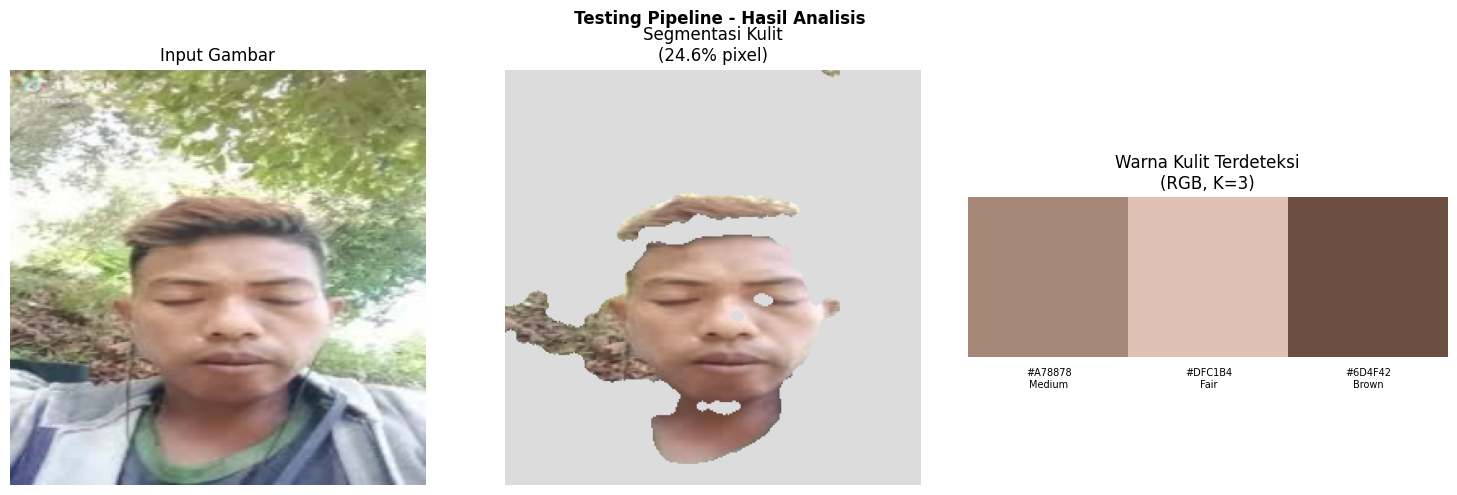


  Cluster Dominan: 1


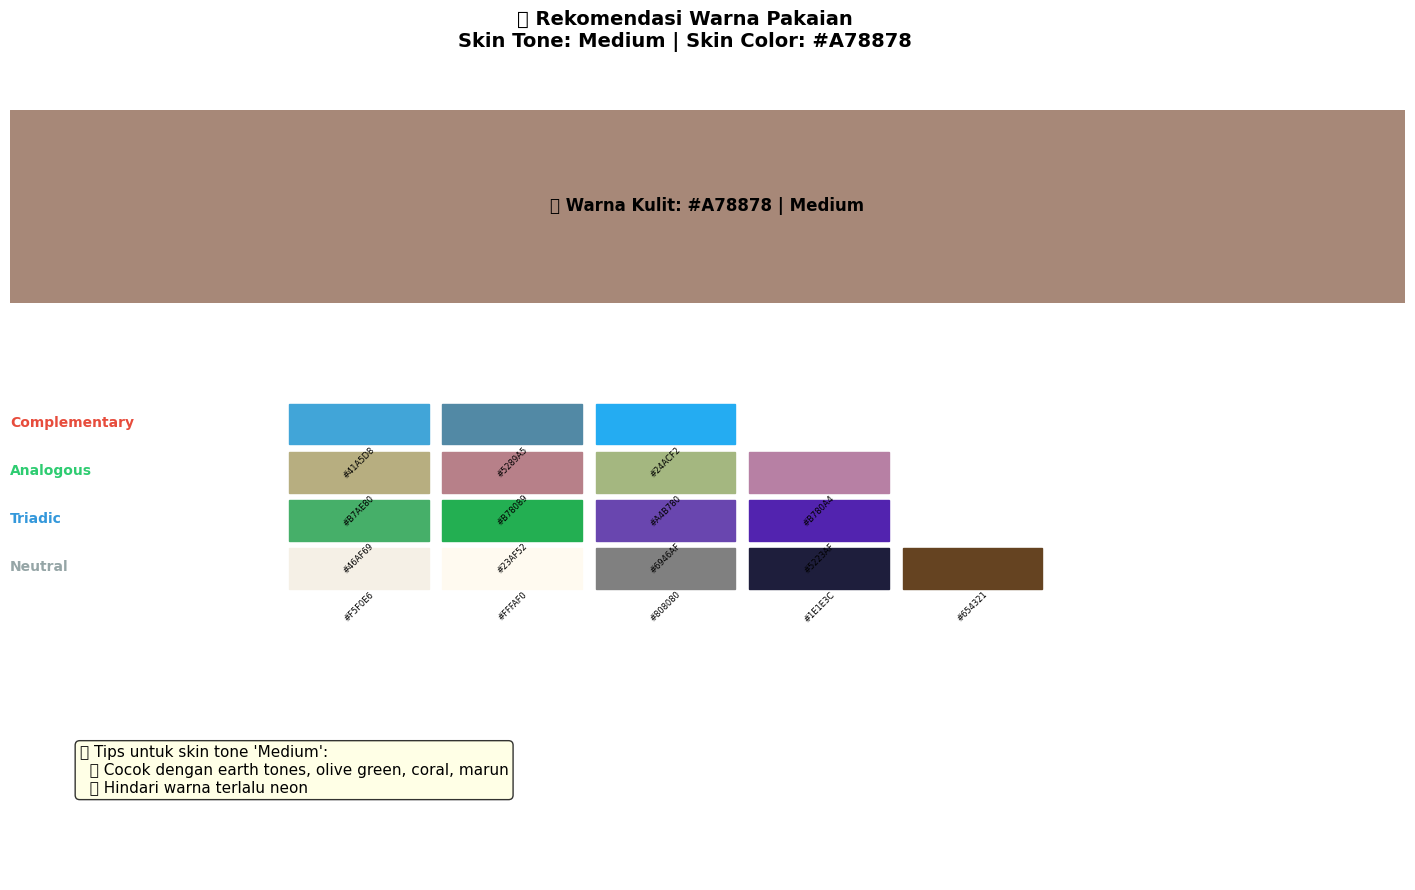

In [ ]:
# ============================================================
# 🧪 PIPELINE TESTING UNTUK GAMBAR BARU (INTERAKTIF)
# ============================================================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_skin_and_recommend(img_input, color_space=None, k=None, verbose=True):
    """
    Pipeline lengkap: dari gambar baru → rekomendasi warna pakaian.
    """
    cs = color_space or best_cs
    k  = k or best_k

    # 1. Load gambar
    if isinstance(img_input, str):
        img_bgr = cv2.imread(img_input)
        if img_bgr is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {img_input}")
    else:
        img_bgr = img_input.copy()

    # 2. Resize
    img_bgr = cv2.resize(img_bgr, TARGET_SIZE)

    # 3. Preprocessing
    img_proc = preprocess_image(img_bgr)

    # 4. Segmentasi kulit
    mask, masks_dict = segment_skin_combined(img_proc)

    # 5. Ekstraksi pixel
    pixels, _ = extract_skin_pixels(img_proc, cs)
    if pixels is None or len(pixels) < 50:
        print("☀  Terlalu sedikit pixel kulit terdeteksi.")
        return []

    # 6. K-Means clustering
    actual_k = min(k, len(pixels))
    model, labels, centroids, inertia = run_kmeans(pixels, actual_k)

    # 7. Konversi centroid ke RGB
    centroids_rgb = centroids_rgb_from_space(centroids, cs)

    # 8. Rekomendasi
    recommendations = []
    for c in centroids_rgb:
        rec = get_clothing_recommendations(c)
        recommendations.append(rec)

    if verbose:
        # Visualisasi lengkap
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        skin_overlay = img_rgb.copy()
        skin_overlay[mask == 0] = [220, 220, 220]

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle("  Testing Pipeline - Hasil Analisis", fontsize=12, fontweight='bold')

        axes[0].imshow(img_rgb)
        axes[0].set_title("Input Gambar"); axes[0].axis('off')

        axes[1].imshow(skin_overlay)
        pct = (mask > 0).mean() * 100
        axes[1].set_title(f"Segmentasi Kulit\n({pct:.1f}% pixel)")
        axes[1].axis('off')

        palette_img = np.zeros((80, len(centroids_rgb) * 80, 3), dtype=np.uint8)
        for i, c in enumerate(centroids_rgb):
            palette_img[:, i*80:(i+1)*80, :] = c
        axes[2].imshow(palette_img)
        axes[2].set_title(f"Warna Kulit Terdeteksi\n({cs}, K={actual_k})")
        for i, c in enumerate(centroids_rgb):
            hex_str = '#{:02X}{:02X}{:02X}'.format(*c)
            tone = classify_skin_tone(c)
            axes[2].text(i*80+40, 85, f"{hex_str}\n{tone}", ha='center', va='top', fontsize=7)
        axes[2].axis('off')

        plt.tight_layout(); plt.show()

        dominant_idx = np.bincount(labels).argmax()
        print(f"\n  Cluster Dominan: {dominant_idx + 1}")
        visualize_recommendations(recommendations[dominant_idx])

    return recommendations

# ---   UPLOAD IMAGE DAN RUN TEST ---
print("  Unggah gambar dari komputer Anda untuk pengujian:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'\n  Memproses file: "{fn}"')
    recs = predict_skin_and_recommend(
        fn,
        color_space=best_cs,
        k=best_k,
        verbose=True
    )


In [ ]:
# ============================================================
# BONUS: EVALUASI WARNA MENGGUNAKAN CIEDE2000
# Mengukur perbedaan perseptual antara centroid dan warna referensi
# ============================================================

import numpy as np
# Monkey patch np.asscalar if it doesn't exist
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda x: x.item()

def rgb_to_lab_colormath(rgb):
    """Konversi RGB ke LAB menggunakan colormath."""
    srgb = sRGBColor(rgb[0]/255, rgb[1]/255, rgb[2]/255)
    lab  = convert_color(srgb, LabColor)
    return lab


def compute_ciede2000(rgb1, rgb2):
    """Hitung jarak perceptual CIEDE2000 antara dua warna RGB."""
    lab1 = rgb_to_lab_colormath(rgb1)
    lab2 = rgb_to_lab_colormath(rgb2)
    return delta_e_cie2000(lab1, lab2)


def evaluate_recommendation_diversity(rec):
    """
    Ukur diversitas palette rekomendasi menggunakan CIEDE2000.
    Semakin tinggi rata-rata jarak, semakin beragam pilihannya.
    """
    all_colors = rec['all_colors'][:8]  # Ambil 8 warna pertama
    distances  = []
    for i in range(len(all_colors)):
        for j in range(i+1, len(all_colors)):
            d = compute_ciede2000(all_colors[i], all_colors[j])
            distances.append(d)
    avg_dist = np.mean(distances) if distances else 0
    return avg_dist, distances


print("🎨 Evaluasi CIEDE2000 untuk setiap cluster...\n")
print(f"{'Cluster':<10} {'Skin Tone':<12} {'Skin Hex':<10} "
      f"{'Avg CIEDE2000':>15} {'Diversity':>10}")
print("-" * 62)

for i, c in enumerate(best_centroids_rgb):
    rec = get_clothing_recommendations(c)
    avg_d, _ = evaluate_recommendation_diversity(rec)
    diversity = "Tinggi" if avg_d > 40 else ("Sedang" if avg_d > 20 else "Rendah")
    print(f"{i+1:<10} {rec['skin_tone']:<12} {rec['skin_hex']:<10} "
          f"{avg_d:>15.2f} {diversity:>10}")

print("\nℹ️  CIEDE2000 > 2 = dapat dibedakan mata manusia")
print("   CIEDE2000 > 10 = perbedaan jelas")
print("   CIEDE2000 > 40 = kontras sangat tinggi")

🎨 Evaluasi CIEDE2000 untuk setiap cluster...

Cluster    Skin Tone    Skin Hex     Avg CIEDE2000  Diversity
--------------------------------------------------------------
1          Medium       #B4816A              36.04     Sedang
2          Brown        #764D3C              34.90     Sedang
3          Fair         #E5B6A1              38.43     Sedang

ℹ️  CIEDE2000 > 2 = dapat dibedakan mata manusia
   CIEDE2000 > 10 = perbedaan jelas
   CIEDE2000 > 40 = kontras sangat tinggi


### ☁️ Opsional: Mount Google Drive
Jika Anda ingin menggunakan gambar yang tersimpan di Google Drive Anda, jalankan cell di bawah ini untuk menghubungkan Drive Anda ke Colab.

## 📝 13. Kesimpulan & Insight

In [ ]:
# ============================================================
# 📝 KESIMPULAN AKHIR
# ============================================================

print("=" * 65)
print("   📝 KESIMPULAN PENELITIAN")
print("=" * 65)

# 1. Color space terbaik
best_row = df_ranked.iloc[0]
print(f"""
1. 🏆 COLOR SPACE TERBAIK: {best_cs}
   ─────────────────────────────────────────
   Color space {best_cs} menghasilkan cluster yang paling optimal
   berdasarkan skor komposit dari 4 metrik:
   • Silhouette Score        : {best_row['silhouette']:.4f}
   • Davies-Bouldin Index    : {best_row['davies_bouldin']:.4f}
   • Calinski-Harabasz Index : {best_row['calinski_harabasz']:.2f}
   • Stability Score         : {best_row['Stability Score']:.4f}
   • Composite Score         : {best_row['composite']:.4f}
""")

# 2. K terbaik
print(f"""2. 🎯 K TERBAIK: {best_k}
   ─────────────────────────────────────────
   K={best_k} memberikan keseimbangan terbaik antara:
   • Granularitas representasi warna kulit
   • Stabilitas cluster (tidak overfitting)
   • Computational efficiency
   Auto-detect Elbow Method merekomendasikan K={best_k_rgb} untuk RGB.
""")

# 3. Perbandingan color space
print("""3. 🌈 PERBANDINGAN COLOR SPACE:
   ─────────────────────────────────────────
   • RGB   : Intuitif, mudah diinterpretasi, tapi sensitif terhadap
             pencahayaan karena channels tidak terpisah dari luminansi.
   • HSV   : Lebih robust terhadap perubahan intensitas cahaya karena
             memisahkan hue dari brightness. Efektif untuk threshold.
   • LAB   : Perceptually uniform (jarak Euclidean ≈ persepsi manusia),
             paling robust terhadap pencahayaan, ideal untuk CIEDE2000.
             Namun lebih kompleks secara komputasional.
""")

# 4. Segmentasi kulit
print("""4. 🎯 METODE SEGMENTASI KULIT:
   ─────────────────────────────────────────
   Kombinasi voting 3 metode (RGB + HSV + YCrCb) terbukti lebih
   robust dibanding metode tunggal:
   • Mengurangi false positive dari satu metode saja
   • Voting majority (≥2 dari 3) memberikan mask lebih bersih
   • Morphological post-processing menyempurnakan tepi mask
""")

# 5. Sistem rekomendasi
print("""5. 👕 SISTEM REKOMENDASI WARNA:
   ─────────────────────────────────────────
   Rekomendasi berbasis 4 prinsip color harmony:
   • Complementary  : Kontras tinggi, visual paling mencolok
   • Analogous      : Harmonis & elegan, cocok untuk formal wear
   • Triadic        : Balance antara kontras dan harmoni
   • Neutral        : Versatile, cocok untuk semua skin tone

   Evaluasi CIEDE2000 memastikan perbedaan warna rekomendasi
   signifikan secara perseptual (tidak terlalu mirip satu sama lain).
""")

# 6. Keterbatasan & saran
print("""6. 🔮 KETERBATASAN & SARAN PENGEMBANGAN:
   ─────────────────────────────────────────
   • Dataset sintetis → gunakan dataset wajah nyata (e.g., CelebA)
   • Threshold rule-based → eksplorasi deep learning (U-Net, DeepLab)
   • Rekomendasi bisa dipersonalisasi dengan preferensi pengguna
   • Integrasikan faktor musim, occasion, dan tren fashion terkini
""")

print("=" * 65)
print("   ✅ Pipeline selesai & siap digunakan!")
print("=" * 65)

   📝 KESIMPULAN PENELITIAN

1. 🏆 COLOR SPACE TERBAIK: RGB
   ─────────────────────────────────────────
   Color space RGB menghasilkan cluster yang paling optimal
   berdasarkan skor komposit dari 4 metrik:
   • Silhouette Score        : 0.4797
   • Davies-Bouldin Index    : 0.6602
   • Calinski-Harabasz Index : 6799.84
   • Stability Score         : 0.0204
   • Composite Score         : 0.9958

2. 🎯 K TERBAIK: 3
   ─────────────────────────────────────────
   K=3 memberikan keseimbangan terbaik antara:
   • Granularitas representasi warna kulit
   • Stabilitas cluster (tidak overfitting)
   • Computational efficiency
   Auto-detect Elbow Method merekomendasikan K=4 untuk RGB.

3. 🌈 PERBANDINGAN COLOR SPACE:
   ─────────────────────────────────────────
   • RGB   : Intuitif, mudah diinterpretasi, tapi sensitif terhadap
             pencahayaan karena channels tidak terpisah dari luminansi.
   • HSV   : Lebih robust terhadap perubahan intensitas cahaya karena
             memisahkan hue

🎮 Demo Interaktif - Sistem Rekomendasi Warna Pakaian

Menguji 6 variasi warna kulit berbeda (Fitzpatrick Scale):



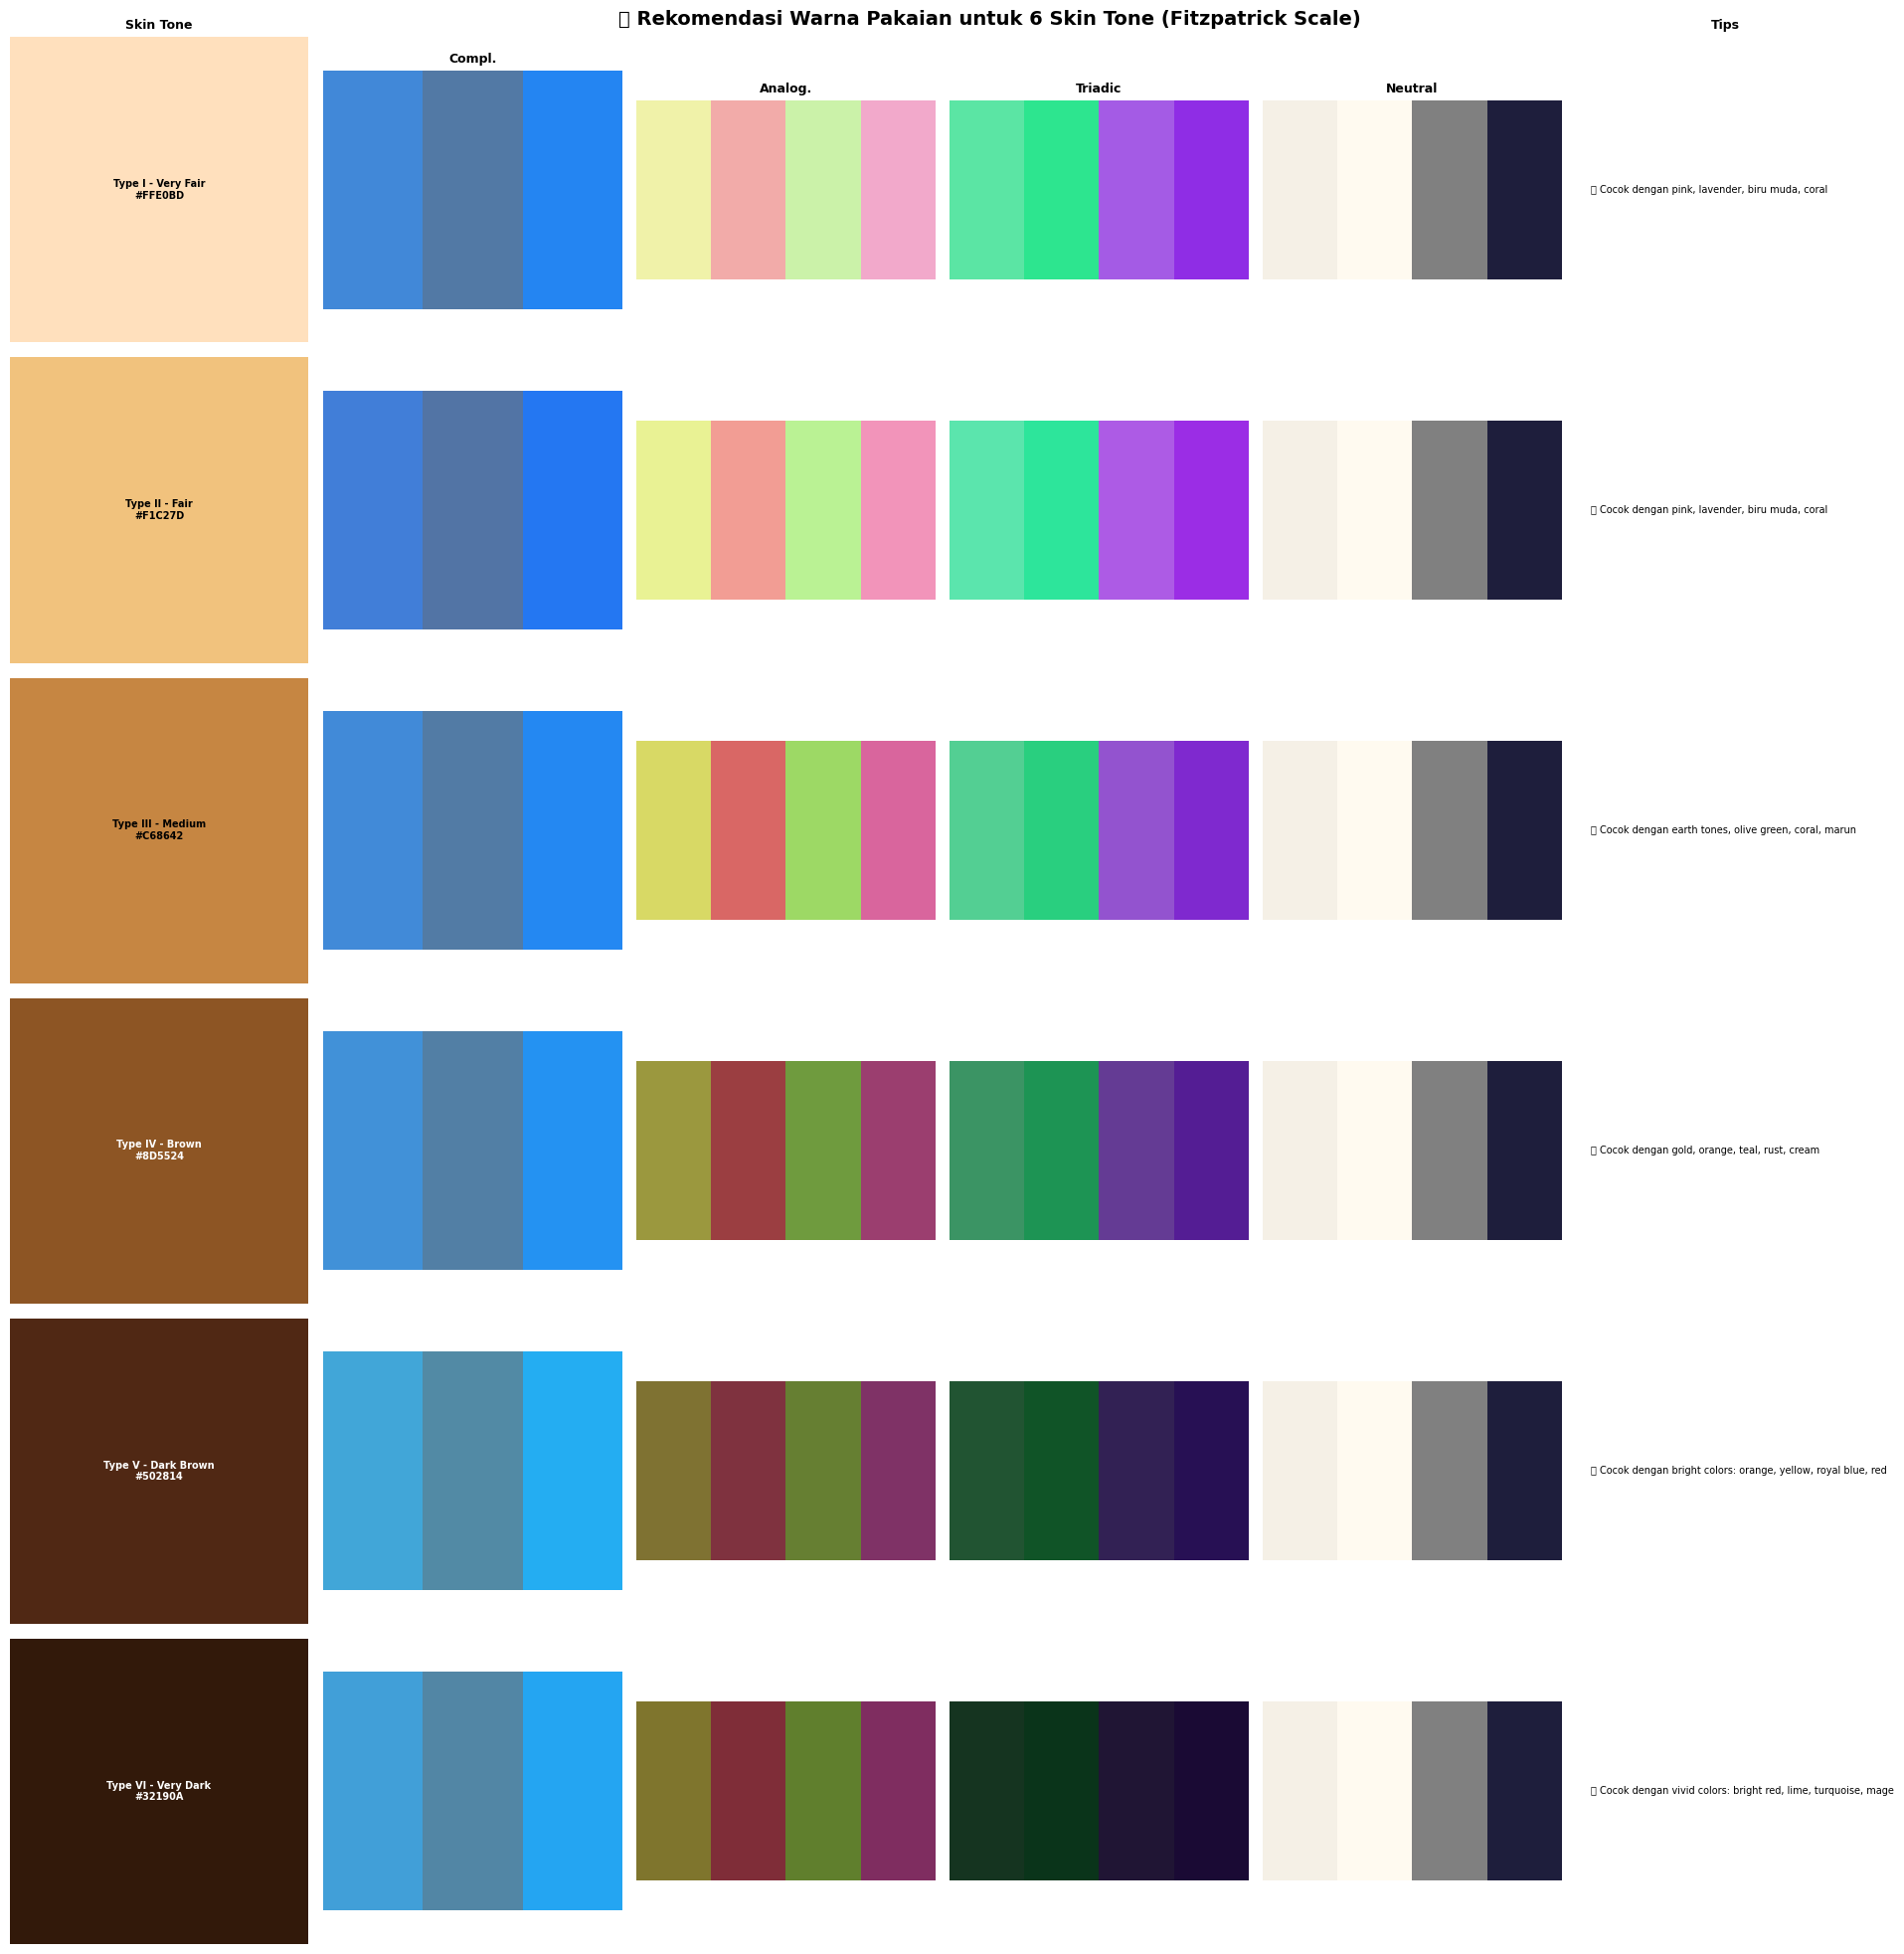


💾 Demo tersimpan di: /content/demo_recommendation_all_tones.png

🎉 SELESAI! Notebook berhasil dijalankan dari awal hingga akhir.


In [ ]:
# ============================================================
# 🎮 DEMO INTERAKTIF: Uji berbagai warna kulit
# ============================================================

print("🎮 Demo Interaktif - Sistem Rekomendasi Warna Pakaian\n")
print("Menguji 6 variasi warna kulit berbeda (Fitzpatrick Scale):\n")

demo_skin_tones = [
    ((255, 224, 189), "Type I - Very Fair"),
    ((241, 194, 125), "Type II - Fair"),
    ((198, 134,  66), "Type III - Medium"),
    ((141,  85,  36), "Type IV - Brown"),
    ((80,   40,  20), "Type V - Dark Brown"),
    ((50,   25,  10), "Type VI - Very Dark"),
]

fig, axes = plt.subplots(6, 6, figsize=(20, 20))
fig.suptitle("👕 Rekomendasi Warna Pakaian untuk 6 Skin Tone (Fitzpatrick Scale)",
             fontsize=14, fontweight='bold')

harmony_types = ['complementary', 'analogous', 'triadic', 'neutral']

for row_idx, (skin_rgb, label) in enumerate(demo_skin_tones):
    rec = get_clothing_recommendations(skin_rgb)

    # Col 0: Warna kulit
    axes[row_idx, 0].add_patch(
        plt.Rectangle((0,0), 1, 1,
                       color=[x/255 for x in skin_rgb])
    )
    txt_color = 'white' if skin_rgb[0] < 150 else 'black'
    axes[row_idx, 0].text(0.5, 0.5, f"{label}\n{rec['skin_hex']}",
                           ha='center', va='center', fontsize=7,
                           color=txt_color, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # Col 1-4: Satu warna per kategori harmony
    for col_idx, harm_type in enumerate(harmony_types, start=1):
        colors = rec[harm_type]
        # Buat palette mini dengan 3-4 warna
        n = min(4, len(colors))
        palette_img = np.zeros((60, n * 25, 3), dtype=np.uint8)
        for j in range(n):
            palette_img[:, j*25:(j+1)*25, :] = np.array(colors[j][:3])
        axes[row_idx, col_idx].imshow(palette_img)
        axes[row_idx, col_idx].set_title(
            harm_type.capitalize() if row_idx == 0 else "",
            fontsize=8
        )
        axes[row_idx, col_idx].axis('off')

    # Col 5: Tip singkat
    axes[row_idx, 5].axis('off')
    strategy = rec.get('strategy', {})
    tip = strategy.get('prefer', '')[:60]
    axes[row_idx, 5].text(0.05, 0.5, f"✅ {tip}",
                           transform=axes[row_idx, 5].transAxes,
                           fontsize=7, va='center', wrap=True)

# Header kolom
col_titles = ['Skin Tone', 'Compl.', 'Analog.', 'Triadic', 'Neutral', 'Tips']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/demo_recommendation_all_tones.png',
            dpi=120, bbox_inches='tight')
plt.show()

print("\n💾 Demo tersimpan di: /content/demo_recommendation_all_tones.png")
print("\n🎉 SELESAI! Notebook berhasil dijalankan dari awal hingga akhir.")